# Hito 3 — Detección de Ataques de Presentación en Documentos de Identidad

**Trabajo de Fin de Máster** · Protocolo IJCB PAD-ID Card Challenge (ISO/IEC 30107-3)

Este notebook extiende el trabajo del Hito 2 con los experimentos que quedaron diferidos: ViT-LoRA con protocolo multi-semilla (exp05), DINOv2 con descongelación parcial del backbone (exp06), ablación de dropout al 0.8 sobre todos los modelos (exp07) y una configuración combinada que une los dos mejores hallazgos del Hito 2 en CLIP (exp08).

El sistema es idéntico al del Hito 2: guarda el estado completo tras cada época y reanuda automáticamente si Colab se desconecta. Los experimentos ya completados se saltan sin volver a ejecutarse.

Los resultados se guardan dentro de la misma carpeta de Drive que el Hito 2, bajo los subdirectorios correspondientes a cada experimento nuevo.

Estructura de carpetas en Drive:

    TFM_ID_Cards/
        segmentado/                  imágenes preprocesadas con SAM, solo lectura
        pickles/df_cross.pkl         partición cross-domain, generada en el Hito 2
        hito2/
            exp01_baseline/          experimentos completados en el Hito 2
            exp02_dropout_07/
            exp03_nopad/
            exp04_pad_15/
            exp05_vit_lora/          experimentos nuevos del Hito 3
            exp06_dinov2_unfreeze/
            exp07_dropout_08/
            exp08_clip_best/

## Dependencias

Las mismas librerías que en el Hito 2. Si el entorno ya las tiene instaladas esta celda termina en segundos.

In [ ]:
!pip install -q \
    albumentations>=1.3.0 \
    timm>=0.9.0 \
    open-clip-torch \
    transformers==4.40.0 \
    peft==0.10.0 \
    scipy scikit-learn
!pip install -q timm --upgrade

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


## Configuración y experimentos

El sistema se controla con dos estructuras. La primera, BASE_CONFIG, recoge todos los hiperparámetros compartidos: tamaño de imagen, tamaño de batch, número máximo de épocas, learning rates por arquitectura y parámetros de LoRA. La segunda, EXPERIMENTS_TO_RUN, es la lista de pruebas a ejecutar, donde cada entrada solo especifica lo que difiere del caso base.

El merge de configuraciones combina los diccionarios anidados en lugar de reemplazarlos, de modo que un experimento puede sobreescribir el learning rate de un único modelo sin redefinir la tabla entera.

Los cuatro experimentos nuevos de este hito se añaden al final de EXPERIMENTS_TO_RUN con la misma estructura que los anteriores. Los cuatro primeros (exp01 a exp04) ya tienen resultados guardados en Drive y se saltan automáticamente.

In [ ]:
BASE_CONFIG: dict = {
    # Rutas
    'drive_root':     'TFM_ID_Cards',
    'local_data_dir': '/content/data_tfm',

    # Reproducibilidad
    'data_seed': 42,

    # Imágenes y carga de datos
    'img_size':        224,
    'batch_train':      64,
    'batch_val':       128,
    'num_workers':       2,
    'syn_train_ratio':  0.30,

    # Clasificación multiclase
    'num_classes': 4,
    'class_names': ['bonafide', 'print', 'screen', 'composite'],
    'label_map': {
        'bonafide':  0,
        'print':     1,
        'printed':   1,
        'screen':    2,
        'composite': 3,
    },

    # Cabeza clasificadora compartida por todos los modelos:
    # Linear(head_hidden) -> BN -> Dropout(head_dropout) -> ReLU -> Linear(num_classes)
    'head_hidden': 256,

    # Entrenamiento
    'max_epochs':    150,
    'patience':       20,
    'weight_decay':  1e-2,
    'grad_clip':      1.0,
    'scheduler_type': 'cosine',   # 'cosine' o 'plateau'

    # Learning rates
    'model_lr': {
        'efficientnet_b4':   1e-4,
        'mobilenetv3_large': 1e-4,
        'dinov2':            5e-4,
        'clip':              3e-4,
        'vit_lora':          3e-4,
    },

    # LoRA (experimento 5, diferido al Hito 3)
    'lora_r':       8,
    'lora_alpha':  16,
    'lora_dropout': 0.1,
}


EXPERIMENTS_TO_RUN: list[dict] = [
    {
        'exp_id':           'exp01_baseline',
        'note':             ('Referencia principal. Los cuatro modelos con '
                             'configuracion estandar: dropout 0.5 y padding '
                             'del 8%. Punto de comparacion para el resto.'),
        'models_to_train':  ['efficientnet_b4', 'mobilenetv3_large', 'dinov2', 'clip'],
        'head_dropout':     0.5,
        'context_pad_frac': 0.08,
        'run_seeds':        [0, 1, 2],
    },
    {
        'exp_id':           'exp02_dropout_07',
        'note':             ('Hipotesis: un dropout mas agresivo (0.7) reduce '
                             'el sobreajuste con un dataset de tamano moderado '
                             'y mejora la generalizacion al cambio de dominio '
                             'ID Cards -> SYN PASS.'),
        'models_to_train':  ['efficientnet_b4', 'mobilenetv3_large', 'dinov2', 'clip'],
        'head_dropout':     0.7,
        'context_pad_frac': 0.08,
        'run_seeds':        [0, 1, 2],
    },
    {
        'exp_id':           'exp03_nopad',
        'note':             ('Ablacion de padding: crop de SAM sin margen adicional. '
                             'Limite inferior de la comparativa 0% / 8% / 15%.'),
        'models_to_train':  ['efficientnet_b4', 'dinov2'],
        'head_dropout':     0.5,
        'context_pad_frac': 0.0,
        'run_seeds':        [0, 1, 2],
    },
    {
        'exp_id':           'exp04_pad_15',
        'note':             ('Con margen del 15% el modelo ve bordes del documento: '
                             'filo de pantalla, margen de folio. Hipotesis: ese '
                             'contexto ayuda a detectar ataques screen y print.'),
        'models_to_train':  ['efficientnet_b4', 'dinov2'],
        'head_dropout':     0.5,
        'context_pad_frac': 0.15,
        'run_seeds':        [0, 1, 2],
    },
    {
        'exp_id':               'exp06_dinov2_unfreeze',
        'note':                 ('DINOv2 con los ultimos 4 bloques del ViT '
                                 'descongelados y lr bajo. Contrasta con '
                                 'exp01 donde el backbone esta frozen.'),
        'models_to_train':      ['dinov2'],
        'head_dropout':         0.5,
        'context_pad_frac':     0.08,
        'dinov2_unfreeze_blocks': 4,
        'model_lr':             {'dinov2': 1e-5},
        'run_seeds':            [0, 1, 2],
    },
]

# Hito 3 — experimentos adicionales (añadidos a EXPERIMENTS_TO_RUN)
EXPERIMENTS_TO_RUN += [
    {
        'exp_id':           'exp05_vit_lora',
        'note':             ('ViT-B/16 con LoRA (r=8) sobre Q y V. '
                             'Diferido desde Hito 2.'),
        'models_to_train':  ['vit_lora'],
        'head_dropout':     0.5,
        'context_pad_frac': 0.08,
        'run_seeds':        [0, 1, 2],
    },
    {
        'exp_id':           'exp07_dropout_08',
        'note':             ('Dropout 0.8. Completa la comparativa '
                             '0.5 / 0.7 / 0.8 sobre todos los modelos.'),
        'models_to_train':  ['efficientnet_b4', 'mobilenetv3_large', 'dinov2', 'clip'],
        'head_dropout':     0.8,
        'context_pad_frac': 0.08,
        'run_seeds':        [0, 1, 2],
    },
    {
        'exp_id':           'exp08_clip_best',
        'note':             ('CLIP con la mejor combinacion encontrada en Hito 2: '
                             'dropout=0.7 (exp02) + sin padding (exp03). '
                             'Hipotesis: combinar ambas mejoras da el mejor resultado '
                             'cross-domain para CLIP.'),
        'models_to_train':  ['clip'],
        'head_dropout':     0.7,
        'context_pad_frac': 0.0,
        'run_seeds':        [0, 1, 2],
    },
]


def build_config(base: dict, experiment: dict) -> dict:
    '''Combina la configuracion base con los parametros del experimento.

    Para diccionarios anidados hace merge de claves en lugar de reemplazar
    el diccionario entero, de modo que model_lr puede sobreescribirse
    parcialmente sin redefinir todos los learning rates.
    '''
    config = {**base}
    for key, val in experiment.items():
        if isinstance(val, dict) and isinstance(config.get(key), dict):
            config[key] = {**config[key], **val}
        else:
            config[key] = val
    return config

## Imports, dispositivo y reproducibilidad

La función set_reproducibility fija todas las fuentes de aleatoriedad de Python, NumPy, PyTorch y CUDA antes de cada entrenamiento. Dos runs con la misma semilla producen exactamente los mismos pesos iniciales y el mismo orden de batches, lo que hace las comparaciones entre experimentos estrictamente controladas.

In [ ]:
import os, gc, json, random, shutil, textwrap, subprocess, warnings
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import open_clip
import datetime

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm.notebook import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import det_curve, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit

from google.colab import drive


def setup_device() -> torch.device:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.cuda.is_available():
        r = subprocess.run(
            ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
            capture_output=True, text=True)
        print(f'GPU: {r.stdout.strip()}')
    else:
        warnings.warn('Sin GPU — cambiar Runtime a GPU antes de entrenar.', RuntimeWarning)
    return device


def set_reproducibility(seed: int) -> None:
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


DEVICE      = setup_device()
IMG_SIZE    = BASE_CONFIG['img_size']
LABEL_MAP   = BASE_CONFIG['label_map']
CLASS_NAMES = BASE_CONFIG['class_names']
DATA_SEED   = BASE_CONFIG['data_seed']

set_reproducibility(DATA_SEED)
print(f'Config: epochs={BASE_CONFIG["max_epochs"]} | patience={BASE_CONFIG["patience"]} | clases={BASE_CONFIG["num_classes"]}')
print(f'Experimentos: {len(EXPERIMENTS_TO_RUN)}')
for exp in EXPERIMENTS_TO_RUN:
    print(f'  {exp["exp_id"]:<30} {exp["models_to_train"]}  '
          f'dropout={exp["head_dropout"]}  pad={exp["context_pad_frac"]}  '
          f'runs={len(exp["run_seeds"])}')

GPU: NVIDIA A100-SXM4-40GB, 40960 MiB
Config: epochs=150 | patience=20 | clases=4
Experimentos: 8
  exp01_baseline                 ['efficientnet_b4', 'mobilenetv3_large', 'dinov2', 'clip']  dropout=0.5  pad=0.08  runs=3
  exp02_dropout_07               ['efficientnet_b4', 'mobilenetv3_large', 'dinov2', 'clip']  dropout=0.7  pad=0.08  runs=3
  exp03_nopad                    ['efficientnet_b4', 'dinov2']  dropout=0.5  pad=0.0  runs=3
  exp04_pad_15                   ['efficientnet_b4', 'dinov2']  dropout=0.5  pad=0.15  runs=3
  exp06_dinov2_unfreeze          ['dinov2']  dropout=0.5  pad=0.08  runs=3
  exp05_vit_lora                 ['vit_lora']  dropout=0.5  pad=0.08  runs=3
  exp07_dropout_08               ['efficientnet_b4', 'mobilenetv3_large', 'dinov2', 'clip']  dropout=0.8  pad=0.08  runs=3
  exp08_clip_best                ['clip']  dropout=0.7  pad=0.0  runs=3


## Drive, rutas y verificación del entorno

Esta celda monta Drive, define las rutas de trabajo y verifica que todo esté en orden antes de continuar. Comprueba que la GPU está disponible, que los datos existen en alguna de las tres formas posibles y que todos los modelos definidos en los experimentos tienen un learning rate asignado.

In [ ]:
drive.mount('/content/drive')

DRIVE_ROOT  = Path(f'/content/drive/MyDrive/{BASE_CONFIG["drive_root"]}')
LOCAL_SEG   = Path(f'{BASE_CONFIG["local_data_dir"]}/segmentado')
H1_SEG_DIR  = DRIVE_ROOT / 'segmentado'
PKL_DIR     = DRIVE_ROOT / 'pickles'
PKL_PATH    = PKL_DIR / 'df_cross.pkl'
H2_BASE_DIR = DRIVE_ROOT / 'hito2'

for d in [PKL_DIR, H2_BASE_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def _count_files(directory: Path) -> int:
    return sum(1 for f in directory.rglob('*') if f.is_file()) if directory.exists() else 0


def get_experiment_dirs(exp_id: str) -> dict:
    root = H2_BASE_DIR / exp_id
    dirs = {'root': root, 'checkpoints': root/'checkpoints',
            'resultados': root/'resultados', 'figuras': root/'figuras'}
    for d in dirs.values(): d.mkdir(parents=True, exist_ok=True)
    return dirs


def check_environment(base_config: dict, experiments: list) -> None:
    if not torch.cuda.is_available():
        warnings.warn('Sin GPU.', RuntimeWarning)
    if not DRIVE_ROOT.exists():
        raise RuntimeError(f'Drive no montado o carpeta no encontrada: {DRIVE_ROOT}')

    has_pkl  = PKL_PATH.exists()
    has_seg  = H1_SEG_DIR.exists() and _count_files(H1_SEG_DIR) > 0
    zip_idc  = DRIVE_ROOT / 'Dataset ID CARDS Final.zip'
    zip_syn  = DRIVE_ROOT / 'SYN ID PASS Final.zip'
    has_zips = zip_idc.exists() and zip_syn.exists()

    if not (has_pkl or has_seg or has_zips):
        raise FileNotFoundError(
            f'Sin datos. Se esperaba:\n  A) {PKL_PATH}\n  B) {H1_SEG_DIR}\n  C) ZIPs en {DRIVE_ROOT}')

    for exp in experiments:
        unknown = set(exp['models_to_train']) - set(base_config['model_lr'].keys())
        if unknown:
            raise ValueError(f'{exp["exp_id"]}: sin lr definido para {unknown}')

    estado = 'A-pkl' if has_pkl else ('B-segmentado' if has_seg else 'C-zips')
    print(f'Entorno OK  datos={estado}  experimentos={len(experiments)}')
    print(f'  Drive: {DRIVE_ROOT}')
    print(f'  H2:    {H2_BASE_DIR}')


check_environment(BASE_CONFIG, EXPERIMENTS_TO_RUN)

Mounted at /content/drive
Entorno OK  datos=A-pkl  experimentos=8
  Drive: /content/drive/MyDrive/TFM_ID_Cards
  H2:    /content/drive/MyDrive/TFM_ID_Cards/hito2


In [ ]:
# Verificación de estado antes de entrenar

import os
from pathlib import Path

print("=" * 60)
print("  VERIFICACIÓN PREVIA AL ENTRENAMIENTO")
print("=" * 60)

# GPU
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"\nGPU: {gpu}  ({vram:.0f} GB VRAM)")
else:
    print("\nATENCION: no hay GPU disponible. El entrenamiento será muy lento.")

# Datos
print()
if PKL_PATH.exists():
    import pickle
    size = PKL_PATH.stat().st_size / 1e6
    print(f"Pickle encontrado: df_cross.pkl ({size:.1f} MB)")
    print("El pipeline de datos se salta directamente a la carga del pickle.")
elif H1_SEG_DIR.exists():
    n = sum(1 for _ in H1_SEG_DIR.rglob("*") if Path(_).is_file())
    print(f"Carpeta segmentada encontrada: {n} archivos.")
    print("Se reconstruye el DataFrame sin repetir SAM (~2 min).")
else:
    print("No se encontraron datos preprocesados.")
    print("Se ejecutará el pipeline SAM completo. Duración estimada: 30-90 minutos.")

# Estado de experimentos
print()
print(f"{'Experimento':<28} {'Estado'}")
print("-" * 50)
for exp in EXPERIMENTS_TO_RUN:
    exp_id = exp["exp_id"]
    json_path = H2_BASE_DIR / exp_id / "resultados" / "runs.json"
    if json_path.exists():
        with open(json_path) as jf:
            res = json.load(jf)
        total_runs = sum(len(v) for v in res.values())
        expected   = len(exp["models_to_train"]) * len(exp["run_seeds"])
        if total_runs >= expected:
            estado = f"COMPLETO ({total_runs} runs)"
        else:
            estado = f"En progreso ({total_runs}/{expected} runs)"
    else:
        estado = "Pendiente"
    print(f"  {exp_id:<26} {estado}")

print()
print("=" * 60)

  VERIFICACIÓN PREVIA AL ENTRENAMIENTO

GPU: NVIDIA A100-SXM4-40GB  (42 GB VRAM)

Pickle encontrado: df_cross.pkl (5.1 MB)
El pipeline de datos se salta directamente a la carga del pickle.

Experimento                  Estado
--------------------------------------------------
  exp01_baseline             COMPLETO (17 runs)
  exp02_dropout_07           COMPLETO (12 runs)
  exp03_nopad                COMPLETO (6 runs)
  exp04_pad_15               COMPLETO (6 runs)
  exp06_dinov2_unfreeze      COMPLETO (3 runs)
  exp05_vit_lora             COMPLETO (3 runs)
  exp07_dropout_08           COMPLETO (12 runs)
  exp08_clip_best            En progreso (2/3 runs)



## Pipeline de datos

Esta celda solo necesita ejecutarse una vez por sesión. El pipeline detecta automáticamente el estado de Drive y actúa en consecuencia: si el pickle ya existe lo carga directamente; si está la carpeta segmentada del Hito 2 reconstruye el DataFrame sin repetir la segmentación; solo si no hay nada de lo anterior procesa los ZIPs originales con SAM desde cero.

La segmentación con SAM extrae el documento del fondo antes de entrenar. Los experimentos exp03, exp01 y exp04 prueban cuánto contexto conviene conservar añadiendo un margen de 0%, 8% y 15% sobre ese recorte.

In [ ]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def _find_segmented_roots(seg_dir: Path):
    idc = next((seg_dir/d for d in ['ID_CARDS','ID CARDS','IDCARDS'] if (seg_dir/d).exists()), None)
    syn = next((seg_dir/d for d in ['SYN_PASS','SYN PASS','SYNPASS'] if (seg_dir/d).exists()), None)
    return idc, syn

def _build_dataframe(root: Path, include_country: bool = False) -> pd.DataFrame:
    records = []
    for path, dirs, files in os.walk(root):
        dirs[:] = [d for d in dirs if d not in {'__MACOSX', '.DS_Store'}]
        parts = Path(path).relative_to(root).parts
        attack_type = next((p for p in parts if p in LABEL_MAP), None)
        if attack_type is None: continue
        for fn in files:
            if Path(fn).suffix.lower() not in IMG_EXTS: continue
            rec = {'ruta': str(Path(path)/fn), 'tipo': attack_type,
                   'etiqueta_binaria': int(attack_type != 'bonafide'),
                   'document_id': fn.split('_')[0]}
            if include_country: rec['country'] = parts[0] if parts else 'unknown'
            records.append(rec)
    return pd.DataFrame(records)

def _build_cross_domain_split(df_idc, df_syn, syn_train_ratio, data_seed):
    rng = np.random.default_rng(data_seed)
    idc = df_idc.copy(); syn = df_syn.copy()
    idc['document_id'] = 'idc_' + idc['document_id'].astype(str)
    syn['document_id'] = 'syn_' + syn['document_id'].astype(str)
    idc['source'] = 'idcards'; syn['source'] = 'synpass'

    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=data_seed)
    tr_idx, va_idx = next(gss.split(idc, groups=idc['document_id']))
    idc['split'] = 'unassigned'
    idc.iloc[tr_idx, idc.columns.get_loc('split')] = 'train'
    idc.iloc[va_idx, idc.columns.get_loc('split')] = 'val'

    if not syn.empty:
        docs = syn['document_id'].unique()
        tr_doc = rng.choice(docs, size=max(1, int(len(docs)*syn_train_ratio)), replace=False)
        syn['split'] = 'test_syn'
        syn.loc[syn['document_id'].isin(tr_doc), 'split'] = 'train'

    df = pd.concat([idc, syn], ignore_index=True)
    ids = {s: set(df.loc[df['split']==s,'document_id']) for s in ['train','val','test_syn']}
    assert not (ids['train'] & ids['val']),     'Leakage train/val'
    assert not (ids['train'] & ids['test_syn']), 'Leakage train/test'
    assert not (ids['val']   & ids['test_syn']), 'Leakage val/test'
    return df

def _segmentar_con_sam(image, sam_model, sam_processor, margin_px=8):
    w, h = image.size
    inputs = sam_processor(images=image, input_points=[[[w//2, h//2]]], return_tensors='pt').to(DEVICE)
    with torch.no_grad(): outputs = sam_model(**inputs)
    masks  = sam_processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(), inputs['original_sizes'].cpu(), inputs['reshaped_input_sizes'].cpu())
    scores    = outputs.iou_scores[0,0].cpu()
    best_mask = masks[0][0][scores.argmax()].numpy().astype(bool)
    ratio     = best_mask.sum() / (h * w)
    if not (0.05 <= ratio <= 0.90):
        mx, my = int(w*0.08), int(h*0.08)
        return image.crop((mx, my, w-mx, h-my)), 'fallback'
    rows = np.where(best_mask.any(axis=1))[0]; cols = np.where(best_mask.any(axis=0))[0]
    x1,y1 = max(0,cols[0]-margin_px), max(0,rows[0]-margin_px)
    x2,y2 = min(w,cols[-1]+margin_px), min(h,rows[-1]+margin_px)
    return image.crop((x1,y1,x2,y2)), 'sam'

def _run_sam_pipeline(dataframe, sam_model, sam_processor, seg_dir, local_data_dir):
    paths, methods = [], []
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        src = row['ruta']
        dst = seg_dir / Path(src).relative_to(local_data_dir)
        dst.parent.mkdir(parents=True, exist_ok=True)
        if dst.exists():
            paths.append(str(dst)); methods.append('cached'); continue
        try:
            crop, method = _segmentar_con_sam(Image.open(src).convert('RGB'), sam_model, sam_processor)
            crop.save(str(dst)); paths.append(str(dst)); methods.append(method)
        except Exception:
            shutil.copy2(src, str(dst)); paths.append(str(dst)); methods.append('error')
    df = dataframe.copy(); df['ruta'] = paths; df['seg_method'] = methods
    return df

if PKL_PATH.exists():
    print(f'Pkl encontrado: {PKL_PATH}')
elif H1_SEG_DIR.exists() and _count_files(H1_SEG_DIR) > 0:
    print('Carpeta segmentada encontrada. Reconstruyendo DataFrame...')
    idc_root, syn_root = _find_segmented_roots(H1_SEG_DIR)
    df_idc = _build_dataframe(idc_root)
    df_syn = _build_dataframe(syn_root, include_country=True) if syn_root else pd.DataFrame(columns=list(df_idc.columns)+['country'])
    print(f'  ID Cards: {len(df_idc)} | SYN PASS: {len(df_syn)}')
    df_cross_new = _build_cross_domain_split(df_idc, df_syn, BASE_CONFIG['syn_train_ratio'], DATA_SEED)
    df_cross_new.to_pickle(str(PKL_PATH)); print(f'  Guardado: {len(df_cross_new)} filas')
else:
    print('Ejecutando pipeline SAM completo (30-90 min)...')
    import zipfile
    local_idc = Path(BASE_CONFIG['local_data_dir'])/'ID_CARDS'
    local_syn = Path(BASE_CONFIG['local_data_dir'])/'SYN_PASS'
    local_idc.mkdir(parents=True, exist_ok=True); local_syn.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(DRIVE_ROOT/'Dataset ID CARDS Final.zip') as z: z.extractall(local_idc)
    with zipfile.ZipFile(DRIVE_ROOT/'SYN ID PASS Final.zip')       as z: z.extractall(local_syn)
    df_raw_idc = _build_dataframe(local_idc/'Dataset ID CARDS Final')
    df_raw_syn = _build_dataframe(local_syn/'SYN ID PASS Final', include_country=True)
    from transformers import SamModel, SamProcessor
    _sam_proc  = SamProcessor.from_pretrained('facebook/sam-vit-base')
    _sam_model = SamModel.from_pretrained('facebook/sam-vit-base').to(DEVICE); _sam_model.eval()
    df_idc_seg = _run_sam_pipeline(df_raw_idc, _sam_model, _sam_proc, LOCAL_SEG, BASE_CONFIG['local_data_dir'])
    df_syn_seg = _run_sam_pipeline(df_raw_syn, _sam_model, _sam_proc, LOCAL_SEG, BASE_CONFIG['local_data_dir'])
    del _sam_model, _sam_proc; gc.collect(); torch.cuda.empty_cache()
    if not H1_SEG_DIR.exists(): shutil.copytree(str(LOCAL_SEG), str(H1_SEG_DIR), dirs_exist_ok=True)
    df_cross_c = _build_cross_domain_split(df_idc_seg, df_syn_seg, BASE_CONFIG['syn_train_ratio'], DATA_SEED)
    df_cross_c.to_pickle(str(PKL_PATH)); print(f'  Guardado: {len(df_cross_c)} filas')

Pkl encontrado: /content/drive/MyDrive/TFM_ID_Cards/pickles/df_cross.pkl


## Carga del dataset y splits

El pickle se carga una vez al inicio de la sesión. Los DataLoaders se reconstruyen para cada experimento porque el margen de contexto puede variar entre ellos.

El split de test corresponde a SYN PASS, pasaportes sintéticos de un dominio distinto al de entrenamiento. Cualquier evaluación sobre test es por tanto un escenario cross-domain real: el modelo nunca ha visto ese tipo de documento durante el ajuste. SYN PASS no contiene ataques de tipo compuesto, de modo que esa clase tiene cero muestras en test por diseño del dataset.

In [ ]:
def _remap_paths_to_drive(dataframe, drive_seg_dir: Path):
    if os.path.exists(dataframe['ruta'].iloc[0]): return dataframe
    index  = {f.name: str(f) for f in drive_seg_dir.rglob('*') if f.is_file()}
    result = dataframe.copy()
    result['ruta'] = result['ruta'].apply(lambda p: index.get(Path(p).name, p))
    n_ok = result['ruta'].apply(os.path.exists).sum()
    print(f'Rutas remapeadas: {n_ok}/{len(result)} válidas')
    if n_ok < len(result) * 0.95: warnings.warn(f'Solo {n_ok}/{len(result)} rutas resueltas.')
    return result

def _verify_no_leakage(train_df, val_df, test_df) -> None:
    tr,va,te = set(train_df['document_id']), set(val_df['document_id']), set(test_df['document_id'])
    assert not (tr & va), f'Leakage train/val: {tr & va}'
    assert not (tr & te), 'Leakage train/test'
    assert not (va & te), 'Leakage val/test'

def _print_split_summary(train_df, val_df, test_df, class_names) -> None:
    print(f'  {"Clase":<12} {"Train":>8} {"Val":>7} {"Test":>8} {"Total":>8}')
    print('  ' + '-'*46)
    for idx, name in enumerate(class_names):
        tr = (train_df['etiqueta_multi']==idx).sum()
        va = (val_df['etiqueta_multi']==idx).sum()
        te = (test_df['etiqueta_multi']==idx).sum()
        print(f'  {name:<12} {tr:>8} {va:>7} {te:>8} {tr+va+te:>8}')
    print('  ' + '-'*46)
    t = len(train_df)+len(val_df)+len(test_df)
    print(f'  {"TOTAL":<12} {len(train_df):>8} {len(val_df):>7} {len(test_df):>8} {t:>8}')

print('Cargando datos desde Drive...')
df_cross = pd.read_pickle(str(PKL_PATH))
if 'source' not in df_cross.columns:
    df_cross['source'] = df_cross['document_id'].apply(
        lambda d: 'idcards' if str(d).startswith('idc_') else 'synpass')
df_cross = _remap_paths_to_drive(df_cross, H1_SEG_DIR)
df_cross['etiqueta_multi'] = df_cross['tipo'].map(LABEL_MAP).astype(int)

TRAIN_DF = df_cross[df_cross['split']=='train'].reset_index(drop=True)
VAL_DF   = df_cross[df_cross['split']=='val'].reset_index(drop=True)
TEST_DF  = df_cross[df_cross['split']=='test_syn'].reset_index(drop=True)

_verify_no_leakage(TRAIN_DF, VAL_DF, TEST_DF)
print('Sin leakage entre splits.')
_print_split_summary(TRAIN_DF, VAL_DF, TEST_DF, CLASS_NAMES)

Cargando datos desde Drive...
Sin leakage entre splits.
  Clase           Train     Val     Test    Total
  ----------------------------------------------
  bonafide         3337     593     2115     6045
  print            4332    2947     2161     9440
  screen           3316    2652     2112     8080
  composite        2387     613        0     3000
  ----------------------------------------------
  TOTAL           13372    6805     6388    26565


## Aumentación de datos

El pipeline aplica solo transformaciones fotométricas: compresión JPEG, desenfoque, temperatura de color, ruido ISO, escala de grises y rotaciones leves. Las distorsiones geométricas agresivas se evitan deliberadamente porque destruirían las texturas que son la señal clave para detectar ataques. El patrón de semitono de una impresión o el moiré de una pantalla dependen de la microestructura local de la imagen y no sobreviven a transformaciones que deformen esa estructura.

In [ ]:
_IMAGENET_MEAN = (0.485, 0.456, 0.406)
_IMAGENET_STD  = (0.229, 0.224, 0.225)

def build_train_transforms(img_size: int) -> A.Compose:
    return A.Compose([
        A.Resize(img_size, img_size),
        A.ImageCompression(quality_range=(30, 95), p=0.60),
        A.OneOf([A.GaussianBlur(blur_limit=(3,7),p=1.0),
                 A.MotionBlur(blur_limit=7,p=1.0),
                 A.MedianBlur(blur_limit=5,p=1.0)], p=0.50),
        A.ISONoise(color_shift=(0.01,0.06), intensity=(0.10,0.50), p=0.40),
        A.OneOf([A.RGBShift(r_shift_limit=30,g_shift_limit=10,b_shift_limit=30,p=1.0),
                 A.ColorJitter(brightness=0.35,contrast=0.35,saturation=0.30,hue=0.06,p=1.0)], p=0.65),
        A.ToGray(p=0.12),
        A.Rotate(limit=15, border_mode=0, p=0.50),
        A.HorizontalFlip(p=0.20),
        A.RandomBrightnessContrast(brightness_limit=0.20, contrast_limit=0.20, p=0.40),
        A.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),
        ToTensorV2(),
    ])

def build_val_transforms(img_size: int) -> A.Compose:
    return A.Compose([A.Resize(img_size,img_size),
                      A.Normalize(mean=_IMAGENET_MEAN,std=_IMAGENET_STD), ToTensorV2()])

print('Pipelines de augmentación definidos.')

Pipelines de augmentación definidos.


## Dataset y DataLoaders

El margen de contexto se aplica sobre el recorte de SAM antes de redimensionar, añadiendo contexto reflejado con el modo reflect. Esto evita los bordes negros artificiales que el modelo podría aprender a detectar como señal espuria en lugar de la textura real del ataque.

Para compensar el desbalance de clases se usa una doble estrategia: un sampler ponderado en el DataLoader para que cada clase aparezca con la misma frecuencia esperada en cada época, y pesos en la función de pérdida para que las clases minoritarias contribuyan más al gradiente.

In [ ]:
def _seed_worker(worker_id: int) -> None:
    s = torch.initial_seed() % 2**32
    np.random.seed(s); random.seed(s)

class PADDataset(Dataset):
    '''Dataset multiclase PAD con padding de contexto configurable.'''

    def __init__(self, dataframe, transform, pad_fraction=0.0):
        self.df           = dataframe.reset_index(drop=True)
        self.transform    = transform
        self.pad_fraction = pad_fraction
        self.paths  = self.df['ruta'].tolist()
        self.labels = self.df['etiqueta_multi'].tolist()
        self.types  = self.df['tipo'].tolist()

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        try:
            img = np.array(Image.open(self.paths[idx]).convert('RGB'))
            if self.pad_fraction > 0:
                h, w = img.shape[:2]
                ph, pw = int(h*self.pad_fraction), int(w*self.pad_fraction)
                img = np.pad(img, ((ph,ph),(pw,pw),(0,0)), mode='reflect')
        except Exception:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        return self.transform(image=img)['image'], self.labels[idx], self.types[idx]


def _class_weights_and_sampler(labels, num_classes, seed):
    counts   = np.bincount(labels, minlength=num_classes).astype(float)
    inv_freq = 1.0 / (counts + 1e-6)
    sw       = [float(inv_freq[l]) for l in labels]
    norm     = inv_freq / inv_freq.sum() * num_classes
    cw       = torch.tensor(norm, dtype=torch.float32).to(DEVICE)
    sampler  = WeightedRandomSampler(weights=sw, num_samples=len(sw), replacement=True,
                                     generator=torch.Generator().manual_seed(seed))
    return sw, cw, sampler


def build_dataloaders(train_df, val_df, test_df, config):
    '''Construye los tres DataLoaders para un experimento.

    Los transforms se crean aquí a partir de config['img_size'], lo que permite
    que cada experimento use una resolución distinta sin cambiar código global.
    '''
    pad      = config['context_pad_frac']
    seed     = config['data_seed']
    n_cls    = config['num_classes']
    img_size = config.get('img_size', IMG_SIZE)
    t_train  = build_train_transforms(img_size)
    t_val    = build_val_transforms(img_size)

    _, class_w, sampler = _class_weights_and_sampler(
        train_df['etiqueta_multi'].values, n_cls, seed)
    gen = torch.Generator(); gen.manual_seed(seed)

    ld_tr = DataLoader(PADDataset(train_df, t_train, pad_fraction=pad),
                       batch_size=config['batch_train'], sampler=sampler,
                       num_workers=config['num_workers'], pin_memory=True,
                       worker_init_fn=_seed_worker, generator=gen, drop_last=True)
    ld_va = DataLoader(PADDataset(val_df,  t_val),
                       batch_size=config['batch_val'], shuffle=False,
                       num_workers=config['num_workers'], pin_memory=True)
    ld_te = DataLoader(PADDataset(test_df, t_val),
                       batch_size=config['batch_val'], shuffle=False,
                       num_workers=config['num_workers'], pin_memory=True)

    print(f'  Loaders (pad={pad*100:.0f}%, img={img_size}px): '
          f'train={len(ld_tr.dataset)} val={len(ld_va.dataset)} test={len(ld_te.dataset)}')
    return ld_tr, ld_va, ld_te, class_w

## Arquitecturas

Las cinco arquitecturas comparten la misma cabeza clasificadora: una capa densa de 256 neuronas con batch normalization, dropout configurable y ReLU, seguida de la capa de salida de cuatro clases.

EfficientNet-B4 y MobileNetV3-Large son redes convolucionales con pesos ImageNet donde se descongelan las últimas capas para adaptar el backbone al dominio de documentos de identidad. DINOv2 ViT-B/14 es un Vision Transformer preentrenado con supervisión auto-supervisada sobre 142 millones de imágenes; en el experimento de referencia el backbone está completamente congelado, mientras que exp06 prueba qué ocurre al descongelar los últimos bloques con un learning rate conservador. CLIP ViT-B/32 expone los dos últimos bloques residuales del encoder visual. ViT-LoRA aplica adaptación de bajo rango sobre las proyecciones Query y Value de cada bloque de atención, ajustando el transformer con muy pocos parámetros adicionales.

In [ ]:
def build_classification_head(in_features: int, config: dict) -> nn.Sequential:
    h = config['head_hidden']; d = config['head_dropout']
    return nn.Sequential(
        nn.Linear(in_features, h), nn.BatchNorm1d(h),
        nn.Dropout(p=d), nn.ReLU(inplace=True),
        nn.Linear(h, config['num_classes']))

def _log_params(model, name):
    tot = sum(p.numel() for p in model.parameters())
    tra = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  {name:<32}: {tra:>10,} entrenables / {tot:>12,} ({100*tra/tot:.1f}%)')

class _BackboneWithHead(nn.Module):
    def __init__(self, backbone, head):
        super().__init__(); self.backbone=backbone; self.head=head
    def forward(self, x): return self.head(self.backbone(x))

def build_efficientnet_b4(run_seed, config):
    set_reproducibility(run_seed)
    bb = timm.create_model('efficientnet_b4', pretrained=True, num_classes=0, global_pool='avg')
    for p in bb.parameters(): p.requires_grad = False
    for name, p in bb.named_parameters():
        if any(f'blocks.{i}' in name for i in [5,6]) or 'conv_head' in name:
            p.requires_grad = True
    m = _BackboneWithHead(bb, build_classification_head(bb.num_features, config))
    _log_params(m, 'EfficientNet-B4'); return m

def build_mobilenetv3_large(run_seed, config):
    set_reproducibility(run_seed)
    bb = timm.create_model('mobilenetv3_large_100', pretrained=True, num_classes=0, global_pool='avg')
    for p in bb.parameters(): p.requires_grad = False
    for block_name, _ in list(bb.named_children())[-2:]:
        for p in getattr(bb, block_name).parameters(): p.requires_grad = True
    bb.eval()
    with torch.no_grad(): out_dim = bb(torch.zeros(1,3,IMG_SIZE,IMG_SIZE)).shape[1]
    m = _BackboneWithHead(bb, build_classification_head(out_dim, config))
    _log_params(m, 'MobileNetV3-Large'); return m

def build_dinov2(run_seed, config):
    '''DINOv2 ViT-B/14. Backbone congelado por defecto; dinov2_unfreeze_blocks
    permite descongelar los últimos N bloques para fine-tuning parcial.'''
    set_reproducibility(run_seed)
    bb = timm.create_model('vit_base_patch14_dinov2.lvd142m', pretrained=True,
                            num_classes=0, global_pool='avg', img_size=IMG_SIZE,
                            pretrained_strict=False)
    for p in bb.parameters(): p.requires_grad = False
    n = config.get('dinov2_unfreeze_blocks', 0)
    if n > 0 and hasattr(bb, 'blocks'):
        for blk in list(bb.blocks)[-n:]:
            for p in blk.parameters(): p.requires_grad = True
        if hasattr(bb, 'norm'):
            for p in bb.norm.parameters(): p.requires_grad = True
    m = _BackboneWithHead(bb, build_classification_head(bb.num_features, config))
    _log_params(m, f'DINOv2 ViT-B/14 (unfreeze={n})'); return m

def build_clip(run_seed, config):
    set_reproducibility(run_seed)
    clip_model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
    visual = clip_model.visual
    for p in visual.parameters(): p.requires_grad = False
    if hasattr(visual,'transformer') and hasattr(visual.transformer,'resblocks'):
        for block in list(visual.transformer.resblocks)[-2:]:
            for p in block.parameters(): p.requires_grad = True

    class _CLIPWrapper(nn.Module):
        def __init__(self, enc, hd): super().__init__(); self.backbone=enc; self.head=hd
        def forward(self, x):
            f = self.backbone(x)
            return self.head((f[0] if isinstance(f,tuple) else f).float())

    m = _CLIPWrapper(visual, build_classification_head(visual.output_dim, config))
    _log_params(m, 'CLIP ViT-B/32'); return m

def build_vit_lora(run_seed, config):
    from transformers import ViTForImageClassification
    from peft import get_peft_model, LoraConfig
    set_reproducibility(run_seed)
    base = ViTForImageClassification.from_pretrained(
        'google/vit-base-patch16-224', num_labels=config['num_classes'],
        ignore_mismatched_sizes=True)
    lora_cfg = LoraConfig(r=config['lora_r'], lora_alpha=config['lora_alpha'],
                          target_modules=['query','value'],
                          lora_dropout=config['lora_dropout'], bias='none')
    peft_model = get_peft_model(base, lora_cfg)
    in_f = peft_model.base_model.classifier.in_features
    peft_model.base_model.classifier = build_classification_head(in_f, config)

    class _ViTWrapper(nn.Module):
        def __init__(self, m): super().__init__(); self.model=m
        def forward(self, x): return self.model(pixel_values=x).logits

    m = _ViTWrapper(peft_model); _log_params(m, 'ViT-LoRA'); return m

MODEL_REGISTRY = {
    'efficientnet_b4':   build_efficientnet_b4,
    'mobilenetv3_large': build_mobilenetv3_large,
    'dinov2':            build_dinov2,
    'clip':              build_clip,
    'vit_lora':          build_vit_lora,
}

def get_model(model_name: str, run_seed: int, config: dict) -> nn.Module:
    '''Único punto de entrada para instanciar modelos por nombre.'''
    if model_name not in MODEL_REGISTRY:
        raise ValueError(f'Modelo desconocido: {model_name!r}. Disponibles: {list(MODEL_REGISTRY)}')
    return MODEL_REGISTRY[model_name](run_seed=run_seed, config=config).to(DEVICE)

print('Registro de arquitecturas:', list(MODEL_REGISTRY.keys()))

Registro de arquitecturas: ['efficientnet_b4', 'mobilenetv3_large', 'dinov2', 'clip', 'vit_lora']


## Métricas PAD (ISO/IEC 30107-3)

La conversión de clasificación multiclase a binaria es directa: el score de ataque es uno menos la probabilidad de bonafide, lo que permite usar el protocolo estándar del challenge sin modificar la arquitectura.

AVRank es la métrica oficial del challenge: pondera BPCER a tres puntos de operación forzados (0.2 por APCER al 10%, 0.3 por APCER al 5% y 0.5 por APCER al 1%). El mayor peso en el escenario de APCER al 1% refleja que en aplicaciones reales se tolera muy poco que un ataque pase como genuino. Se reporta además la APCER desagregada por tipo de ataque para identificar cuáles resultan más difíciles de detectar para cada modelo.

In [ ]:
def _compute_eer(labels, scores):
    fpr, fnr, _ = det_curve(labels, scores, pos_label=1)
    idx = np.argmin(np.abs(fpr - fnr))
    return float((fpr[idx] + fnr[idx]) / 2)

def _bpcer_at_apcer(labels, scores, target_apcer):
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    valid = np.where((1.0 - tpr) <= target_apcer)[0]
    return float(fpr[valid[0]]) if len(valid) > 0 else 1.0

def compute_pad_metrics(labels_binary, scores, name='', verbose=True):
    nan_dict = {k: float('nan') for k in
                ['EER','APCER','BPCER','BPCER@APCER10','BPCER@APCER5','BPCER@APCER1','AVRank']}
    if len(np.unique(labels_binary)) < 2:
        warnings.warn(f'[{name}] Solo una clase presente.'); return nan_dict
    eer    = _compute_eer(labels_binary, scores)
    b10    = _bpcer_at_apcer(labels_binary, scores, 0.10)
    b5     = _bpcer_at_apcer(labels_binary, scores, 0.05)
    b1     = _bpcer_at_apcer(labels_binary, scores, 0.01)
    avrank = 0.2*b10 + 0.3*b5 + 0.5*b1
    preds  = (scores >= 0.5).astype(int)
    is_atk = labels_binary == 1; is_gen = labels_binary == 0
    apcer  = float(np.sum((preds==0) & is_atk) / max(is_atk.sum(), 1))
    bpcer  = float(np.sum((preds==1) & is_gen) / max(is_gen.sum(), 1))
    metrics = {'EER':eer,'APCER':apcer,'BPCER':bpcer,
               'BPCER@APCER10':b10,'BPCER@APCER5':b5,'BPCER@APCER1':b1,'AVRank':avrank}
    if verbose:
        pref = f'[{name}] ' if name else ''
        for k,v in metrics.items(): print(f'  {pref}{k:<18} {v:.4f}')
    return metrics

def evaluate_model(model, loader, label='', verbose=True):
    model.eval()
    all_scores, all_labels, all_types = [], [], []
    with torch.no_grad():
        for imgs, multi_labels, atk_types in tqdm(loader, desc=f'Eval {label}', leave=False):
            imgs = imgs.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda'):
                logits = model(imgs)
            probs = F.softmax(logits.float(), dim=1)
            all_scores.extend((1.0 - probs[:,0]).cpu().numpy())
            all_labels.extend((multi_labels != 0).long().numpy())
            all_types.extend(atk_types)
    sc = np.array(all_scores); lb = np.array(all_labels); tp = np.array(all_types)
    metrics = compute_pad_metrics(lb, sc, name=label, verbose=verbose)
    if verbose:
        for t in sorted(x for x in np.unique(tp) if x != 'bonafide'):
            mask = tp==t; atk = lb[mask]==1
            if atk.sum() == 0: continue
            pred = (sc[mask] >= 0.5).astype(int)
            print(f'    {t:<16}: APCER={np.sum((pred==0)&atk)/atk.sum():.4f}  (n={atk.sum()})')
    return metrics

def aggregate_runs(run_metrics: list) -> dict:
    return {k: {'mean': float(np.nanmean([m[k] for m in run_metrics])),
                'std':  float(np.nanstd( [m[k] for m in run_metrics], ddof=1))}
            for k in run_metrics[0].keys()}

print('Métricas PAD definidas.')

Métricas PAD definidas.


## Motor de entrenamiento

El bucle usa AdamW con scheduler coseno y precisión mixta automática. Tras cada época guarda dos checkpoints: uno de reanudación con el estado completo del optimizador y el scheduler, para tolerar desconexiones de Colab, y uno del mejor modelo con solo los pesos para evaluar después. La configuración exacta se guarda dentro del checkpoint, de modo que cualquier archivo puede cargarse meses después sabiendo con exactitud con qué parámetros se entrenó.

In [ ]:
def _build_optimizer_scheduler_scaler(model, model_name, config):
    lr    = config['model_lr'][model_name]
    opt   = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                               lr=lr, weight_decay=config['weight_decay'])
    stype = config.get('scheduler_type', 'cosine')
    if stype == 'plateau':
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode='min', patience=5, factor=0.5, min_lr=lr*0.01)
    else:
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=config['max_epochs'], eta_min=lr*0.01)
    return opt, sch, torch.amp.GradScaler('cuda')

def _load_checkpoint(path, model, optimizer, scheduler, scaler):
    empty = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'lr':[]}
    if not os.path.exists(path): return 0, float('inf'), 0, empty
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    scaler.load_state_dict(ckpt['scaler_state'])
    return ckpt['epoch']+1, ckpt['best_val_loss'], ckpt['patience_counter'], ckpt['history']

def _train_epoch(model, loader, optimizer, criterion, scaler, grad_clip, tag, epoch, max_epochs):
    model.train(); tl=tc=n=0
    for imgs, labels, _ in tqdm(loader, desc=f'[{tag}] E{epoch+1:03d}/{max_epochs} train', leave=False):
        imgs=imgs.to(DEVICE,non_blocking=True); labels=labels.to(DEVICE,non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            logits=model(imgs); loss=criterion(logits,labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer); scaler.update()
        tl+=loss.item()*imgs.size(0); tc+=(logits.argmax(1)==labels).sum().item(); n+=imgs.size(0)
    return tl/n, tc/n

def _val_epoch(model, loader, criterion, tag, epoch, max_epochs):
    model.eval(); tl=tc=n=0
    with torch.no_grad():
        for imgs, labels, _ in tqdm(loader, desc=f'[{tag}] E{epoch+1:03d}/{max_epochs} val  ', leave=False):
            imgs=imgs.to(DEVICE,non_blocking=True); labels=labels.to(DEVICE,non_blocking=True)
            with torch.amp.autocast('cuda'):
                logits=model(imgs); loss=criterion(logits,labels)
            tl+=loss.item()*imgs.size(0); tc+=(logits.argmax(1)==labels).sum().item(); n+=imgs.size(0)
    return tl/n, tc/n

def _save_resume(path, epoch, model, opt, sch, scaler, best_val, patience_ctr, history, config=None):
    payload = {'epoch':epoch, 'model_state':model.state_dict(),
               'optimizer_state':opt.state_dict(), 'scheduler_state':sch.state_dict(),
               'scaler_state':scaler.state_dict(), 'best_val_loss':best_val,
               'patience_counter':patience_ctr, 'history':history}
    if config is not None:
        payload['config_snapshot'] = {k:v for k,v in config.items()
                                       if isinstance(v,(int,float,str,bool,list,dict))}
    torch.save(payload, path)

def train_model(model_name, run_seed, loader_train, loader_val, class_weights, config, ckpt_dir):
    tag         = f'{model_name}_run{run_seed}'
    ckpt_resume = str(ckpt_dir / f'{tag}_resume.pt')
    ckpt_best   = str(ckpt_dir / f'{tag}_best.pt')

    set_reproducibility(run_seed)
    model     = get_model(model_name, run_seed=run_seed, config=config)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    opt, sch, scaler = _build_optimizer_scheduler_scaler(model, model_name, config)
    start, best_val, patience_ctr, history = _load_checkpoint(ckpt_resume, model, opt, sch, scaler)
    is_plateau = isinstance(sch, torch.optim.lr_scheduler.ReduceLROnPlateau)

    if start > 0:
        print(f'[{tag}] Reanudando desde época {start} | best={best_val:.4f} | pat={patience_ctr}/{config["patience"]}')
    else:
        print(f'[{tag}] Empezando desde cero.')

    for epoch in range(start, config['max_epochs']):
        tr_loss, tr_acc = _train_epoch(model, loader_train, opt, criterion, scaler,
                                       config['grad_clip'], tag, epoch, config['max_epochs'])
        va_loss, va_acc = _val_epoch(model, loader_val, criterion, tag, epoch, config['max_epochs'])

        if is_plateau:
            sch.step(va_loss)
        else:
            sch.step()
        cur_lr = opt.param_groups[0]['lr']

        history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc);     history['lr'].append(cur_lr)

        print(f'[{tag}] E{epoch+1:03d}/{config["max_epochs"]} | '
              f'loss {tr_loss:.4f}/{va_loss:.4f} | '
              f'acc {tr_acc:.3f}/{va_acc:.3f} | '
              f'lr {cur_lr:.2e} | pat {patience_ctr}/{config["patience"]}')

        if va_loss < best_val:
            best_val=va_loss; patience_ctr=0
            torch.save(model.state_dict(), ckpt_best)
            print(f'  -> nuevo mejor  val_loss={best_val:.4f}')
        else:
            patience_ctr += 1

        _save_resume(ckpt_resume, epoch, model, opt, sch, scaler,
                     best_val, patience_ctr, history, config=config)

        if patience_ctr >= config['patience']:
            print(f'[{tag}] Early stopping en época {epoch+1}.'); break

    if os.path.exists(ckpt_best):
        model.load_state_dict(torch.load(ckpt_best, map_location=DEVICE, weights_only=True))
        print(f'[{tag}] Listo. best_val_loss={best_val:.4f}')
    else:
        warnings.warn(f'[{tag}] No se encontró checkpoint del mejor modelo.')
    return model, history

print('Motor de entrenamiento definido.')

Motor de entrenamiento definido.


## Gestión de experimentos

La función run_experiment coordina un experimento completo. La primera vez que arranca guarda un config.json con los parámetros exactos, de modo que el experimento es autocontenido. Los resultados se guardan en JSON inmediatamente tras cada run, de manera que si Colab cae entre dos runs el siguiente arranque salta los ya completados y continúa desde el siguiente.

In [ ]:
def load_experiment_results(results_json):
    if os.path.exists(results_json):
        with open(results_json) as f: results = json.load(f)
        print(f'  Retomando resultados previos: {results_json}')
        for mn, runs in results.items():
            print(f'    {mn}: {len(runs)} runs completados')
        return results
    return {}

def save_experiment_results(results, results_json):
    with open(results_json, 'w') as f: json.dump(results, f, indent=2)

def run_experiment(exp_config, base_config, train_df, val_df, test_df):
    config    = build_config(base_config, exp_config)
    exp_id    = exp_config['exp_id']
    dirs      = get_experiment_dirs(exp_id)
    json_path = str(dirs['resultados'] / 'runs.json')

    # Guardar config la primera vez para reproducibilidad futura
    config_path = dirs['resultados'] / 'config.json'
    if not config_path.exists():
        safe = {k:v for k,v in config.items() if isinstance(v,(int,float,str,bool,list,dict))}
        with open(config_path,'w') as f: json.dump(safe,f,indent=2)

    print(f'\n{"="*65}')
    print(f'  EXPERIMENTO : {exp_id}')
    if 'note' in exp_config:
        for line in textwrap.wrap(exp_config['note'], width=58):
            print(f'  HIPÓTESIS   : {line}')
    print(f'  Modelos     : {exp_config["models_to_train"]}')
    print(f'  Dropout     : {exp_config["head_dropout"]}  '
          f'Pad: {exp_config["context_pad_frac"]*100:.0f}%  '
          f'Runs: {len(exp_config["run_seeds"])}')
    print(f'{"="*65}')

    results = load_experiment_results(json_path)
    loader_train, loader_val, loader_test, class_w = build_dataloaders(
        train_df, val_df, test_df, config)

    for model_name in exp_config['models_to_train']:
        print(f'\n  Modelo: {model_name.upper()}')
        completed = results.get(model_name, [])
        for run_idx, run_seed in enumerate(exp_config['run_seeds']):
            if run_idx < len(completed):
                print(f'  Skip run {run_idx+1}/{len(exp_config["run_seeds"])} seed={run_seed} — ya completado.')
                continue
            print(f'\n  Run {run_idx+1}/{len(exp_config["run_seeds"])}  seed={run_seed}')
            model, _ = train_model(model_name, run_seed, loader_train, loader_val,
                                   class_w, config, ckpt_dir=dirs['checkpoints'])
            gc.collect(); torch.cuda.empty_cache()

            print('\n  Validación (ID Cards):')
            m_val  = evaluate_model(model, loader_val,
                                    label=f'{exp_id}|{model_name}|val|s{run_seed}')
            print('\n  Test (SYN PASS — cross-domain):')
            m_test = evaluate_model(model, loader_test,
                                    label=f'{exp_id}|{model_name}|test|s{run_seed}')

            if model_name not in results: results[model_name] = []
            results[model_name].append({'run_seed':run_seed,'val':m_val,'test':m_test})
            save_experiment_results(results, json_path)
            print(f'  Guardado → {json_path}')
            del model; gc.collect(); torch.cuda.empty_cache()
    return results

print('Gestor de experimentos definido.')

Gestor de experimentos definido.


## Entrenamiento

Al ejecutar esta celda se lanzan todos los experimentos en orden. Los que ya tienen resultados completos en Drive se saltan automáticamente. Si Colab se desconecta a mitad basta con volver a ejecutar la sesión desde el principio y el sistema retoma desde donde lo dejó.

In [ ]:
ALL_RESULTS: dict = {}

for experiment in EXPERIMENTS_TO_RUN:
    ALL_RESULTS[experiment['exp_id']] = run_experiment(
        experiment, BASE_CONFIG, TRAIN_DF, VAL_DF, TEST_DF)

print('\nTodos los experimentos completados.')
for exp_id, results in ALL_RESULTS.items():
    total = sum(len(v) for v in results.values())
    print(f'  {exp_id}: {len(results)} modelos, {total} runs')


  EXPERIMENTO : exp01_baseline
  HIPÓTESIS   : Referencia principal. Los cuatro modelos con configuracion
  HIPÓTESIS   : estandar: dropout 0.5 y padding del 8%. Punto de
  HIPÓTESIS   : comparacion para el resto.
  Modelos     : ['efficientnet_b4', 'mobilenetv3_large', 'dinov2', 'clip']
  Dropout     : 0.5  Pad: 8%  Runs: 3
  Retomando resultados previos: /content/drive/MyDrive/TFM_ID_Cards/hito2/exp01_baseline/resultados/runs.json
    efficientnet_b4: 5 runs completados
    mobilenetv3_large: 5 runs completados
    dinov2: 4 runs completados
    clip: 3 runs completados
  Loaders (pad=8%, img=224px): train=13372 val=6805 test=6388

  Modelo: EFFICIENTNET_B4
  Skip run 1/3 seed=0 — ya completado.
  Skip run 2/3 seed=1 — ya completado.
  Skip run 3/3 seed=2 — ya completado.

  Modelo: MOBILENETV3_LARGE
  Skip run 1/3 seed=0 — ya completado.
  Skip run 2/3 seed=1 — ya completado.
  Skip run 3/3 seed=2 — ya completado.

  Modelo: DINOV2
  Skip run 1/3 seed=0 — ya completado.
  Skip run 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


  CLIP ViT-B/32                   : 14,308,612 entrenables /   87,982,084 (16.3%)
[clip_run2] Reanudando desde época 27 | best=0.7424 | pat=20/20


...

[clip_run2] E028/150 | loss 0.2808/1.6608 | acc 0.892/0.695 | lr 2.75e-04 | pat 20/20
[clip_run2] Early stopping en época 28.
[clip_run2] Listo. best_val_loss=0.7424

  Validación (ID Cards):


Eval exp08_clip_best|clip|val|s2:   0%|          | 0/54 [00:00<?, ?it/s]

  [exp08_clip_best|clip|val|s2] EER                0.0742
  [exp08_clip_best|clip|val|s2] APCER              0.0316
  [exp08_clip_best|clip|val|s2] BPCER              0.2462
  [exp08_clip_best|clip|val|s2] BPCER@APCER10      0.0506
  [exp08_clip_best|clip|val|s2] BPCER@APCER5       0.1180
  [exp08_clip_best|clip|val|s2] BPCER@APCER1       0.5295
  [exp08_clip_best|clip|val|s2] AVRank             0.3103
    composite       : APCER=0.1011  (n=613)
    print           : APCER=0.0159  (n=2947)
    screen          : APCER=0.0328  (n=2652)

  Test (SYN PASS — cross-domain):


Eval exp08_clip_best|clip|test|s2:   0%|          | 0/50 [00:00<?, ?it/s]

  [exp08_clip_best|clip|test|s2] EER                0.0015
  [exp08_clip_best|clip|test|s2] APCER              0.0023
  [exp08_clip_best|clip|test|s2] BPCER              0.0005
  [exp08_clip_best|clip|test|s2] BPCER@APCER10      0.0000
  [exp08_clip_best|clip|test|s2] BPCER@APCER5       0.0000
  [exp08_clip_best|clip|test|s2] BPCER@APCER1       0.0000
  [exp08_clip_best|clip|test|s2] AVRank             0.0000
    printed         : APCER=0.0000  (n=2161)
    screen          : APCER=0.0047  (n=2112)
  Guardado → /content/drive/MyDrive/TFM_ID_Cards/hito2/exp08_clip_best/resultados/runs.json

Todos los experimentos completados.
  exp01_baseline: 4 modelos, 17 runs
  exp02_dropout_07: 4 modelos, 12 runs
  exp03_nopad: 2 modelos, 6 runs
  exp04_pad_15: 2 modelos, 6 runs
  exp06_dinov2_unfreeze: 1 modelos, 3 runs
  exp05_vit_lora: 1 modelos, 3 runs
  exp07_dropout_08: 4 modelos, 12 runs
  exp08_clip_best: 1 modelos, 3 runs


## Estado de los experimentos

Esta celda muestra cuántos runs han terminado y cuál es el mejor EER alcanzado hasta ahora. Es completamente independiente del entrenamiento y puede ejecutarse en cualquier momento sin interferir con nada que esté corriendo.

In [ ]:
print(f'\n{"EXPERIMENTO":<30} {"MODELO":<22} {"RUNS":>6}  {"EER val":>8}  {"EER test":>9}')
print('─' * 82)
for exp in EXPERIMENTS_TO_RUN:
    j       = H2_BASE_DIR / exp['exp_id'] / 'resultados' / 'runs.json'
    n_seeds = len(exp['run_seeds'])
    if not j.exists():
        for mn in exp['models_to_train']:
            print(f'  {exp["exp_id"]:<28} {mn:<22} {"0/"+str(n_seeds):>6}  {"—":>8}  {"—":>9}')
        continue
    with open(j) as f: res = json.load(f)
    for mn in exp['models_to_train']:
        runs = res.get(mn, []); done = len(runs)
        if runs:
            bv = min(r['val']['EER']  for r in runs)
            bt = min(r['test']['EER'] for r in runs)
            print(f'  {exp["exp_id"]:<28} {mn:<22} '
                  f'{str(done)+"/"+str(n_seeds):>6}  {bv:>8.4f}  {bt:>9.4f}')
        else:
            print(f'  {exp["exp_id"]:<28} {mn:<22} {"0/"+str(n_seeds):>6}  {"—":>8}  {"—":>9}')


EXPERIMENTO                    MODELO                   RUNS   EER val   EER test
──────────────────────────────────────────────────────────────────────────────────
  exp01_baseline               efficientnet_b4           5/3    0.0704     0.0019
  exp01_baseline               mobilenetv3_large         5/3    0.1336     0.0119
  exp01_baseline               dinov2                    4/3    0.1398     0.0071
  exp01_baseline               clip                      3/3    0.1299     0.0028
  exp02_dropout_07             efficientnet_b4           3/3    0.0726     0.0071
  exp02_dropout_07             mobilenetv3_large         3/3    0.1589     0.0261
  exp02_dropout_07             dinov2                    3/3    0.1183     0.0056
  exp02_dropout_07             clip                      3/3    0.0945     0.0024
  exp03_nopad                  efficientnet_b4           3/3    0.0608     0.0020
  exp03_nopad                  dinov2                    3/3    0.0860     0.0025
  exp04_pad_15

## Análisis de resultados

La tabla global recoge todos los experimentos ordenados por AVRank en test. A continuación se incluyen dos análisis más focalizados: la ablación del margen de contexto, que compara los experimentos con 0%, 8% y 15% de padding sobre el recorte de SAM, y el gap de generalización, que mide el salto de rendimiento entre validación y test para cada modelo. Dado que el test es de un dominio distinto, ese gap refleja la capacidad de transferencia real del sistema.

In [ ]:
METRIC_COLS = ['EER','APCER','BPCER','BPCER@APCER10','BPCER@APCER5','BPCER@APCER1','AVRank']

def build_global_summary(experiments, h2_base_dir, metric_cols):
    rows = []
    for exp in experiments:
        json_path = h2_base_dir / exp['exp_id'] / 'resultados' / 'runs.json'
        if not json_path.exists():
            print(f'  Sin resultados para {exp["exp_id"]}'); continue
        with open(json_path) as f: results = json.load(f)
        for model_name, runs in results.items():
            if not runs: continue
            if len(runs) < len(exp['run_seeds']):
                print(f'  Aviso: {exp["exp_id"]}/{model_name} tiene {len(runs)}/{len(exp["run_seeds"])} runs')
            for split in ['val','test']:
                agg = aggregate_runs([r[split] for r in runs])
                row = {'Exp':exp['exp_id'], 'Modelo':model_name,
                       'Dropout':exp['head_dropout'],
                       'Pad':f'{int(exp["context_pad_frac"]*100)}%',
                       'Runs':len(runs), 'Split':split.upper()}
                for k in metric_cols:
                    if k in agg: row[k] = f'{agg[k]["mean"]:.4f} ± {agg[k]["std"]:.4f}'
                rows.append(row)
    return pd.DataFrame(rows)

def _mean(s):
    try: return float(str(s).split(' ±')[0])
    except: return float('nan')

def print_global_summary(df):
    test_rows = df[df['Split']=='TEST'].copy()
    if test_rows.empty: print('Sin resultados de test todavía.'); return
    if 'AVRank' in test_rows.columns:
        test_rows['_s'] = test_rows['AVRank'].apply(_mean)
        test_rows = test_rows.sort_values('_s').drop(columns='_s')
    print('\nRESULTADOS GLOBALES — TEST (ordenado por AVRank)\n')
    cols = ['Exp','Modelo','Dropout','Pad','Runs','EER','AVRank','BPCER@APCER10']
    print(test_rows[[c for c in cols if c in test_rows.columns]].to_string(index=False))

df_global = build_global_summary(EXPERIMENTS_TO_RUN, H2_BASE_DIR, METRIC_COLS)
df_global.to_csv(str(H2_BASE_DIR/'global_summary.csv'), index=False)
print(f'Resumen global guardado: {H2_BASE_DIR}/global_summary.csv')
print_global_summary(df_global)

# Ablación de padding
print('\n' + '─'*60)
print('ABLACIÓN DE PADDING — Test split\n')
abl = df_global[
    (df_global['Exp'].isin(['exp03_nopad','exp01_baseline','exp04_pad_15'])) &
    (df_global['Modelo'].isin(['efficientnet_b4','dinov2'])) &
    (df_global['Split']=='TEST')
][['Modelo','Pad','EER','AVRank']].copy()
if not abl.empty:
    abl['_p'] = abl['Pad'].str.rstrip('%').astype(int)
    print(abl.sort_values(['Modelo','_p']).drop(columns='_p').to_string(index=False))
else:
    print('(sin datos suficientes todavía)')

# Domain gap val - test
print('\n' + '─'*60)
print('DOMAIN GAP (EER_test − EER_val)\n')
gap_rows = []
for exp in EXPERIMENTS_TO_RUN:
    for mn in exp['models_to_train']:
        rv = df_global[(df_global['Exp']==exp['exp_id'])&(df_global['Modelo']==mn)&(df_global['Split']=='VAL')]
        rt = df_global[(df_global['Exp']==exp['exp_id'])&(df_global['Modelo']==mn)&(df_global['Split']=='TEST')]
        if rv.empty or rt.empty: continue
        ev,et = _mean(rv['EER'].values[0]), _mean(rt['EER'].values[0])
        if not (np.isnan(ev) or np.isnan(et)):
            gap_rows.append({'Exp':exp['exp_id'],'Modelo':mn,
                             'EER_val':f'{ev:.4f}','EER_test':f'{et:.4f}','Gap':f'{et-ev:+.4f}'})
df_gap = pd.DataFrame(gap_rows)
if not df_gap.empty:
    print(df_gap.to_string(index=False))
    gaps = [float(g) for g in df_gap['Gap']]
    print(f'\nGap medio: {np.mean(gaps):+.4f} ± {np.std(gaps):.4f}')
else:
    print('(sin datos suficientes todavía)')

Resumen global guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/global_summary.csv

RESULTADOS GLOBALES — TEST (ordenado por AVRank)

                  Exp            Modelo  Dropout Pad  Runs             EER          AVRank   BPCER@APCER10
exp06_dinov2_unfreeze            dinov2      0.5  8%     3 0.0000 ± 0.0000 0.0000 ± 0.0000 0.0000 ± 0.0000
          exp03_nopad   efficientnet_b4      0.5  0%     3 0.0032 ± 0.0010 0.0000 ± 0.0000 0.0000 ± 0.0000
      exp08_clip_best              clip      0.7  0%     3 0.0018 ± 0.0010 0.0000 ± 0.0000 0.0000 ± 0.0000
       exp05_vit_lora          vit_lora      0.5  8%     3 0.0022 ± 0.0015 0.0001 ± 0.0001 0.0000 ± 0.0000
     exp02_dropout_07              clip      0.7  8%     3 0.0039 ± 0.0017 0.0004 ± 0.0005 0.0000 ± 0.0000
       exp01_baseline   efficientnet_b4      0.5  8%     5 0.0046 ± 0.0026 0.0010 ± 0.0011 0.0000 ± 0.0000
          exp03_nopad            dinov2      0.5  0%     3 0.0051 ± 0.0035 0.0013 ± 0.0023 0.0000 ± 0.0000
     ex

## Visualizaciones

Las curvas de entrenamiento muestran la pérdida de validación por época para todos los runs de cada experimento, lo que permite detectar sobreajuste, convergencia temprana o inestabilidad entre semillas. Las curvas DET muestran el compromiso entre APCER y BPCER para el mejor run de cada modelo en todos los experimentos. Los histogramas de scores muestran la distribución de la probabilidad de ataque para muestras bonafide y de ataque por separado.

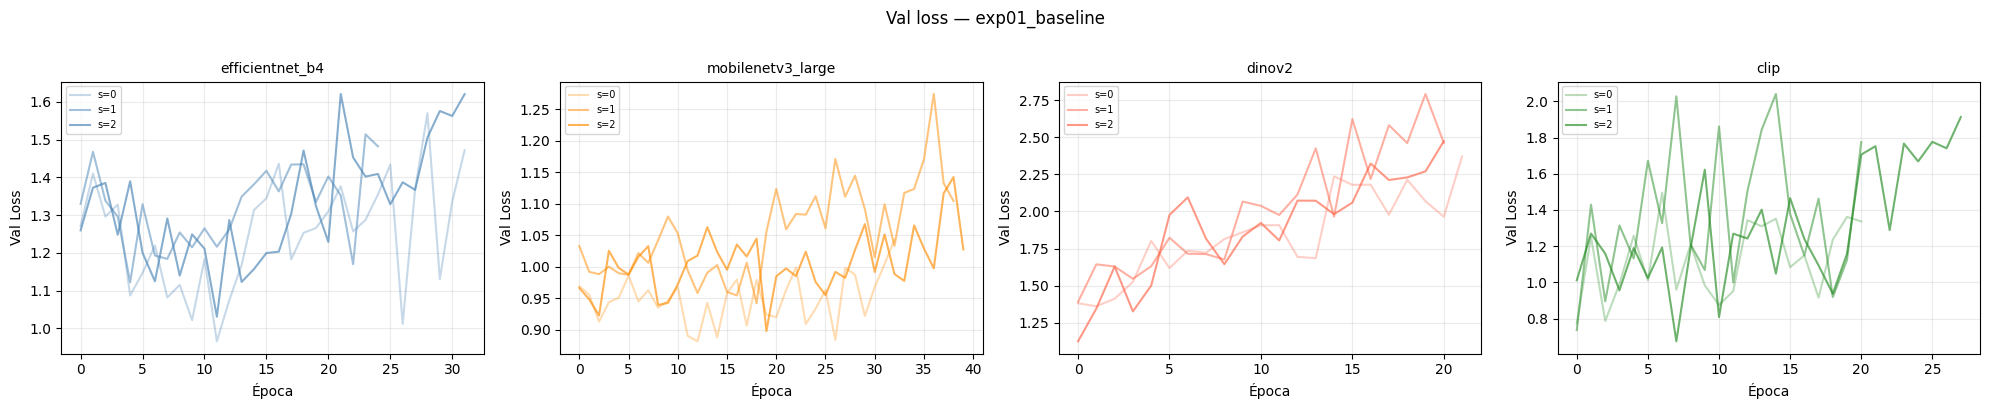

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/exp01_baseline/figuras/training_curves.png


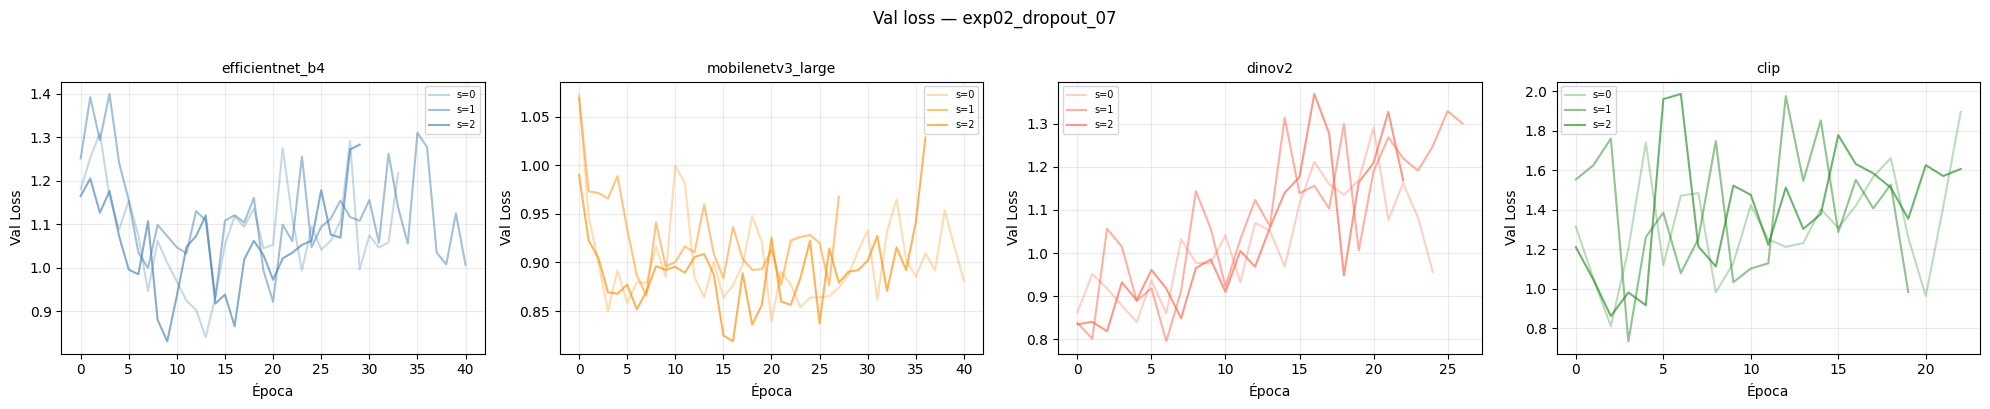

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/exp02_dropout_07/figuras/training_curves.png


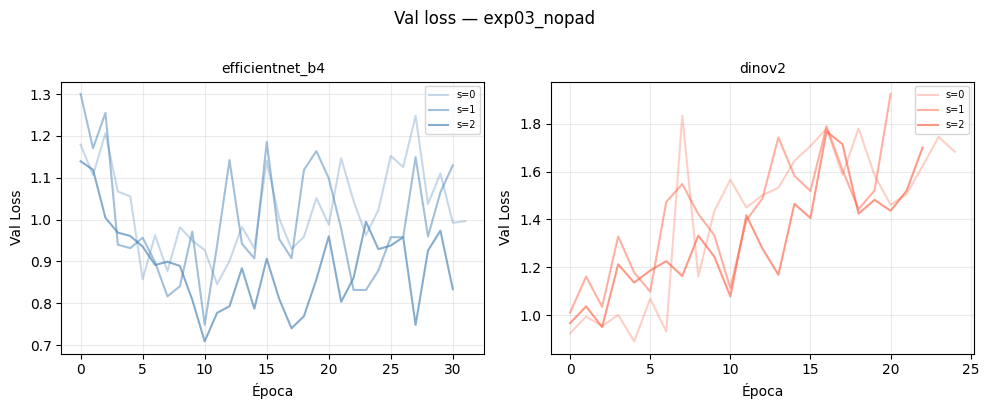

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/exp03_nopad/figuras/training_curves.png


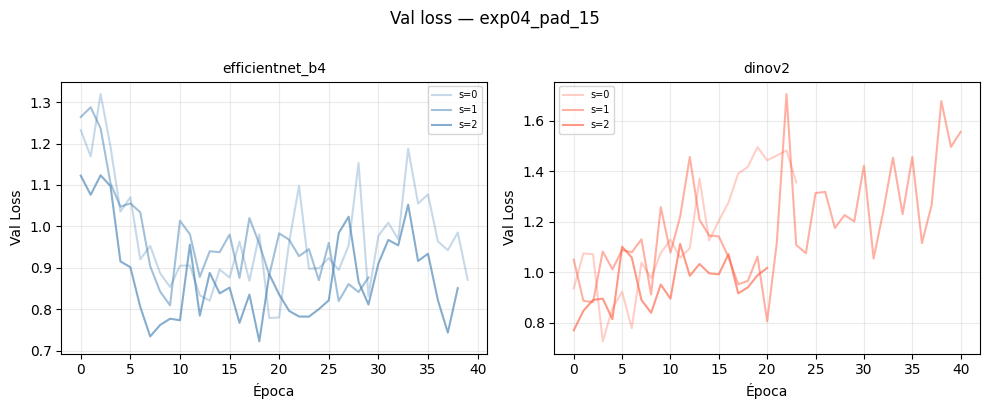

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/exp04_pad_15/figuras/training_curves.png


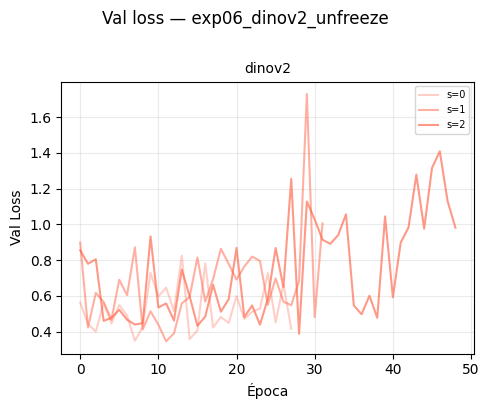

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/exp06_dinov2_unfreeze/figuras/training_curves.png


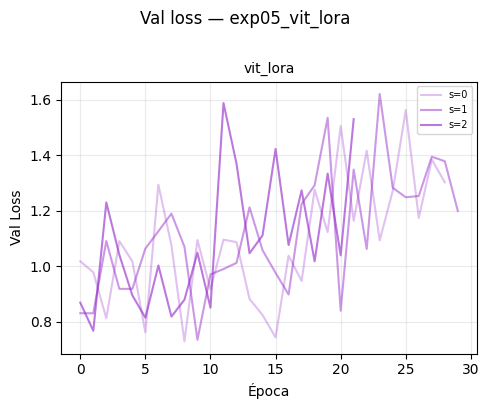

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/exp05_vit_lora/figuras/training_curves.png


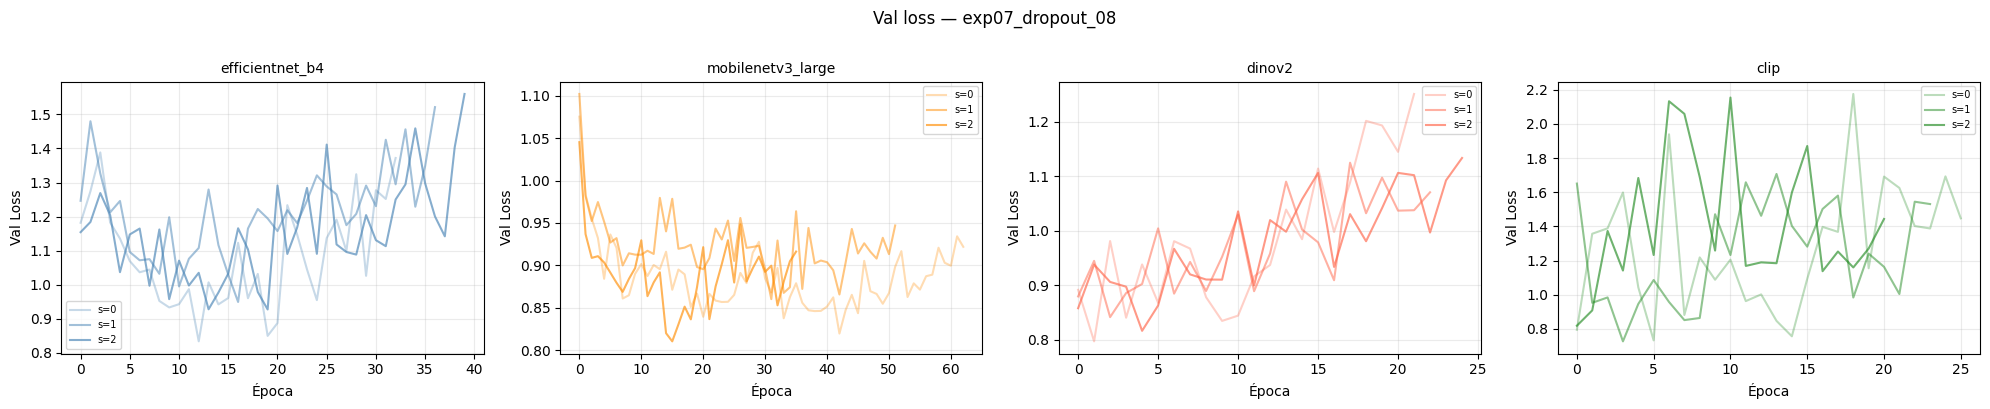

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/exp07_dropout_08/figuras/training_curves.png


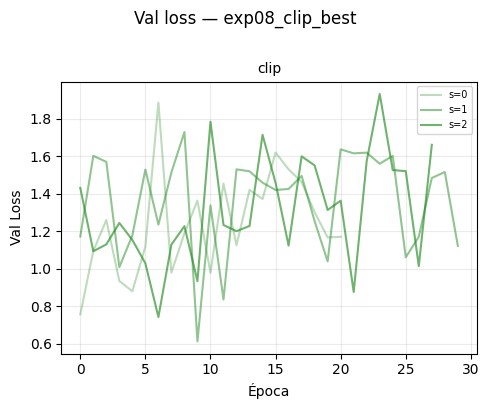

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/exp08_clip_best/figuras/training_curves.png
  Loaders (pad=8%, img=224px): train=13372 val=6805 test=6388


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

  EfficientNet-B4                 : 14,369,596 entrenables /   18,009,164 (79.8%)


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

  MobileNetV3-Large               :    329,476 entrenables /    4,531,508 (7.3%)


...

  DINOv2 ViT-B/14 (unfreeze=0)    :    198,404 entrenables /   85,923,332 (0.2%)


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


  CLIP ViT-B/32                   : 14,308,612 entrenables /   87,982,084 (16.3%)


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


  CLIP ViT-B/32                   : 14,308,612 entrenables /   87,982,084 (16.3%)


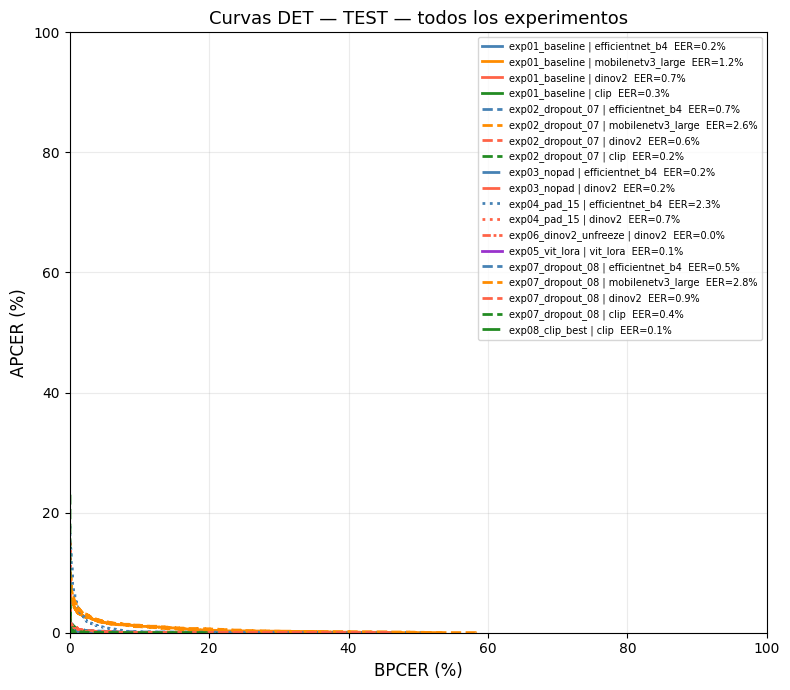

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/det_global_test.png
  Loaders (pad=8%, img=224px): train=13372 val=6805 test=6388
  EfficientNet-B4                 : 14,369,596 entrenables /   18,009,164 (79.8%)
  MobileNetV3-Large               :    329,476 entrenables /    4,531,508 (7.3%)


  DINOv2 ViT-B/14 (unfreeze=0)    :    198,404 entrenables /   85,923,332 (0.2%)


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


  CLIP ViT-B/32                   : 14,308,612 entrenables /   87,982,084 (16.3%)


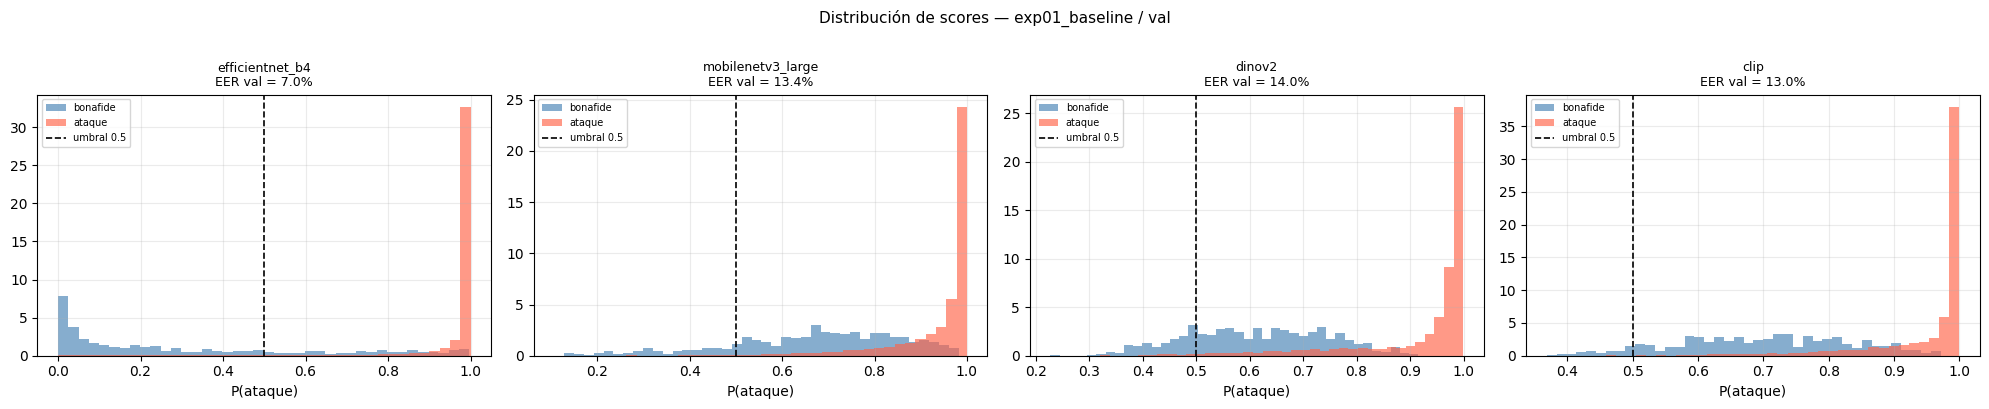

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/score_distributions.png


In [ ]:
MODEL_COLORS = {
    'efficientnet_b4':'steelblue','mobilenetv3_large':'darkorange',
    'dinov2':'tomato','clip':'forestgreen','vit_lora':'darkorchid'}
RUN_ALPHAS = [0.30,0.50,0.65,0.80,1.00]

def plot_training_curves_for_experiment(exp_config, ckpt_dir, fig_dir):
    models=exp_config['models_to_train']; seeds=exp_config['run_seeds']
    fig,axes=plt.subplots(1,len(models),figsize=(5*len(models),4))
    if len(models)==1: axes=[axes]
    for ax,mn in zip(axes,models):
        color=MODEL_COLORS.get(mn,'gray')
        for idx,seed in enumerate(seeds):
            ckpt=ckpt_dir/f'{mn}_run{seed}_resume.pt'
            if not ckpt.exists(): continue
            hist=torch.load(str(ckpt),map_location='cpu',weights_only=False)['history']
            ax.plot(hist['val_loss'],color=color,alpha=RUN_ALPHAS[idx%len(RUN_ALPHAS)],lw=1.5,label=f's={seed}')
        ax.set_title(mn,fontsize=10); ax.set_xlabel('Época'); ax.set_ylabel('Val Loss')
        ax.legend(fontsize=7); ax.grid(alpha=0.25)
    plt.suptitle(f'Val loss — {exp_config["exp_id"]}',fontsize=12,y=1.01)
    plt.tight_layout()
    path=str(fig_dir/'training_curves.png')
    fig.savefig(path,dpi=150,bbox_inches='tight'); plt.show(); print(f'Guardado: {path}')

def plot_det_comparison(experiments, all_results, loader, h2_base_dir, split='test'):
    fig,ax=plt.subplots(figsize=(8,7))
    linestyles=['-','--','-.',':',(0,(3,1,1,1))]
    for exp_idx,exp in enumerate(experiments):
        exp_id=exp['exp_id']; exp_res=all_results.get(exp_id,{})
        ckpt_dir=h2_base_dir/exp_id/'checkpoints'
        ls=linestyles[exp_idx%len(linestyles)]; config=build_config(BASE_CONFIG,exp)
        for mn in exp['models_to_train']:
            runs=exp_res.get(mn,[])
            if not runs: continue
            best_idx=int(np.argmin([r[split]['EER'] for r in runs]))
            best_seed=runs[best_idx]['run_seed']  # ← CORREGIDO
            ckpt_best=ckpt_dir/f'{mn}_run{best_seed}_best.pt'
            if not ckpt_best.exists(): continue
            model=get_model(mn,run_seed=best_seed,config=config)
            model.load_state_dict(torch.load(str(ckpt_best),map_location=DEVICE,weights_only=True))
            model.eval(); sc_list,lb_list=[],[]
            with torch.no_grad():
                for imgs,lm,_ in loader:
                    imgs=imgs.to(DEVICE)
                    with torch.amp.autocast('cuda'): logits=model(imgs)
                    probs=F.softmax(logits.float(),dim=1)
                    sc_list.extend((1.0-probs[:,0]).cpu().numpy())
                    lb_list.extend((lm!=0).long().numpy())
            sc=np.array(sc_list); lb=np.array(lb_list)
            eer=runs[best_idx][split]['EER']
            if len(np.unique(lb))>1:
                fpr_d,fnr_d,_=det_curve(lb,sc,pos_label=1)
                ax.plot(fpr_d*100,fnr_d*100,color=MODEL_COLORS.get(mn,'gray'),ls=ls,lw=2.0,
                        label=f'{exp_id} | {mn}  EER={eer*100:.1f}%')
            del model; gc.collect(); torch.cuda.empty_cache()
    ax.set_xlabel('BPCER (%)',fontsize=12); ax.set_ylabel('APCER (%)',fontsize=12)
    ax.set_title(f'Curvas DET — {split.upper()} — todos los experimentos',fontsize=13)
    ax.legend(fontsize=7,loc='upper right'); ax.grid(alpha=0.25)
    ax.set_xlim(0,100); ax.set_ylim(0,100); plt.tight_layout()
    path=str(h2_base_dir/f'det_global_{split}.png')
    fig.savefig(path,dpi=150,bbox_inches='tight'); plt.show(); print(f'Guardado: {path}')

def plot_score_distributions(experiments, all_results, train_df, val_df, test_df, h2_base_dir):
    exp=next((e for e in experiments if e['exp_id']=='exp01_baseline'),experiments[0])
    exp_res=all_results.get(exp['exp_id'],{})
    if not exp_res: print('Sin resultados para distribución de scores.'); return
    config=build_config(BASE_CONFIG,exp)
    _,loader_val,_,_=build_dataloaders(train_df,val_df,test_df,config)
    models_ok=[mn for mn in exp['models_to_train'] if exp_res.get(mn)]
    if not models_ok: return
    fig,axes=plt.subplots(1,len(models_ok),figsize=(5*len(models_ok),4))
    if len(models_ok)==1: axes=[axes]
    for ax,mn in zip(axes,models_ok):
        runs=exp_res.get(mn,[])
        best_idx=int(np.argmin([r['val']['EER'] for r in runs]))
        best_seed=runs[best_idx]['run_seed']  # ← CORREGIDO
        ckpt_best=h2_base_dir/exp['exp_id']/'checkpoints'/f'{mn}_run{best_seed}_best.pt'
        if not ckpt_best.exists(): ax.set_title(f'{mn}\n(checkpoint no encontrado)'); continue
        model=get_model(mn,run_seed=best_seed,config=config)
        model.load_state_dict(torch.load(str(ckpt_best),map_location=DEVICE,weights_only=True))
        model.eval(); scores,labels=[],[]
        with torch.no_grad():
            for imgs,lm,_ in loader_val:
                imgs=imgs.to(DEVICE)
                with torch.amp.autocast('cuda'): logits=model(imgs)
                probs=F.softmax(logits.float(),dim=1)
                scores.extend((1.0-probs[:,0]).cpu().numpy())
                labels.extend((lm!=0).long().numpy())
        del model; gc.collect(); torch.cuda.empty_cache()
        sc,lb=np.array(scores),np.array(labels)
        ax.hist(sc[lb==0],bins=40,alpha=0.65,label='bonafide',color='steelblue',density=True)
        ax.hist(sc[lb==1],bins=40,alpha=0.65,label='ataque',  color='tomato',   density=True)
        ax.axvline(0.5,ls='--',color='k',lw=1.2,label='umbral 0.5')
        ax.set_title(f'{mn}\nEER val = {runs[best_idx]["val"]["EER"]*100:.1f}%',fontsize=9)
        ax.set_xlabel('P(ataque)'); ax.legend(fontsize=7); ax.grid(alpha=0.25)
    plt.suptitle(f'Distribución de scores — exp01_baseline / val',fontsize=11,y=1.01)
    plt.tight_layout()
    path=str(h2_base_dir/'score_distributions.png')
    fig.savefig(path,dpi=150,bbox_inches='tight'); plt.show(); print(f'Guardado: {path}')

# Generar todas las visualizaciones
for exp in EXPERIMENTS_TO_RUN:
    dirs=get_experiment_dirs(exp['exp_id'])
    if _count_files(dirs['checkpoints'])>0:
        plot_training_curves_for_experiment(exp,dirs['checkpoints'],dirs['figuras'])

loader_test_global=None
for exp in EXPERIMENTS_TO_RUN:
    if ALL_RESULTS.get(exp['exp_id']):
        _,_,loader_test_global,_=build_dataloaders(TRAIN_DF,VAL_DF,TEST_DF,build_config(BASE_CONFIG,exp)); break
if loader_test_global:
    plot_det_comparison(EXPERIMENTS_TO_RUN,ALL_RESULTS,loader_test_global,H2_BASE_DIR)
    plot_score_distributions(EXPERIMENTS_TO_RUN,ALL_RESULTS,TRAIN_DF,VAL_DF,TEST_DF,H2_BASE_DIR)

## Recortes para figuras de la memoria

Genera recortes representativos de cada tipo de ataque en formato horizontal. Cada imagen se rota a landscape si es necesario y se recorta la región central para hacer zoom en la textura del documento. Los archivos PNG resultantes se guardan en Drive para insertarlos directamente en LaTeX.

In [ ]:
CROPS_DIR  = H2_BASE_DIR / 'crops_figuras'
CROPS_DIR.mkdir(parents=True, exist_ok=True)

N_MUESTRAS = 3      # imágenes por tipo de ataque
ZOOM_FRAC  = 0.80   # fracción central conservada (zoom sobre textura del documento)
RNG_CROPS  = np.random.default_rng(42)

TIPO_LABEL = {
    'bonafide':  'Bonafide',
    'print':     'Print attack',
    'screen':    'Screen capture',
    'composite': 'Composite',
}

In [ ]:
def _a_landscape(img):
    """Rota a horizontal si el crop está en portrait."""
    return img.rotate(90, expand=True) if img.height > img.width else img

def _recorte_central(img, frac):
    """Recorta la región central para hacer zoom en la textura."""
    w, h = img.size
    mw, mh = int(w*(1-frac)/2), int(h*(1-frac)/2)
    return img.crop((mw, mh, w-mw, h-mh))

def _hacer_collage(imgs_tipo, titulo, path_out, tw=320, th=200, gap=10):
    tipos  = [t for t in CLASS_NAMES if t in imgs_tipo]
    ancho  = N_MUESTRAS*tw + (N_MUESTRAS+1)*gap
    alto   = len(tipos)*th + (len(tipos)+1)*gap + 40
    lienzo = Image.new('RGB', (ancho, alto), (20, 20, 20))
    draw   = ImageDraw.Draw(lienzo)
    try:
        ft = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 16)
        fl = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 13)
    except Exception:
        ft = fl = ImageFont.load_default()
    draw.text((gap, 10), titulo, fill=(255, 255, 255), font=ft)
    for r, tipo in enumerate(tipos):
        for c, img in enumerate(imgs_tipo[tipo][:N_MUESTRAS]):
            x = gap + c*(tw+gap)
            y = 40  + gap + r*(th+gap)
            lienzo.paste(img.resize((tw, th), Image.LANCZOS), (x, y))
            draw.rectangle([x, y, x+tw-1, y+th-1], outline=(55, 55, 55), width=1)
            if c == 0:
                draw.text((x+5, y+5), TIPO_LABEL.get(tipo, tipo), fill=(255, 210, 60), font=fl)
    lienzo.save(str(path_out), dpi=(300, 300))
    print(f'  collage  - {path_out.name}')

def _generar_latex(crops_guardados, ds_nombre, path_tex):
    """
    Genera un snippet .tex con subcaption listo para pegar en Overleaf.
    Requiere en el preámbulo: \\usepackage{subcaption}
    """
    tipos  = [t for t in CLASS_NAMES if t in crops_guardados]
    ancho  = f'{round(1.0/N_MUESTRAS - 0.02, 2):.2f}'
    ds_fmt = ds_nombre.replace('_', ' ')
    lines  = [
        r'% ──────────────────────────────────────────────────────────────────',
        f'% Crops de ataques — {ds_fmt}  (generado automáticamente)',
        r'% Requiere \usepackage{subcaption} en el preámbulo',
        r'% ──────────────────────────────────────────────────────────────────',
        r'\begin{figure}[ht]',
        r'  \centering',
    ]
    for tipo in tipos:
        fnames = crops_guardados[tipo]
        for i, fname in enumerate(fnames):
            lines.append(f'  \\begin{{subfigure}}[b]{{{ancho}\\linewidth}}')
            lines.append(f'    \\includegraphics[width=\\linewidth]{{figuras/crops/{fname}}}')
            lines.append(r'  \end{subfigure}\hfill')
        lines.append(r'  \\[4pt]')  # separación entre filas de tipo
    lines += [
        f'  \\caption{{Ejemplos representativos de cada categoría de ataque en {ds_fmt}.'
        f' De arriba abajo: \\textit{{bonafide}}, \\textit{{print attack}},'
        f' \\textit{{screen capture}} y \\textit{{composite}}.'
        f' Recorte SAM rotado a horizontal con zoom sobre la región del documento.}}',
        f'  \\label{{fig:crops_{ds_nombre.lower()}}}',
        r'\end{figure}',
        '',
    ]
    path_tex.write_text('\n'.join(lines), encoding='utf-8')
    print(f'  LaTeX    - {path_tex.name}')

# generación
for ds_nombre, df in [('ID_Cards', VAL_DF), ('SYN_PASS', TEST_DF)]:
    print(f'\n── {ds_nombre} ──')
    imgs_por_tipo   = {}
    crops_guardados = {}

    for tipo in CLASS_NAMES:
        variantes = ['print', 'printed'] if tipo == 'print' else [tipo]
        sub = df[df['tipo'].isin(variantes)]
        if sub.empty:
            print(f'  {tipo}: sin muestras'); continue

        idx   = RNG_CROPS.choice(len(sub), size=min(N_MUESTRAS, len(sub)), replace=False)
        imgs, fnames = [], []
        for _, fila in sub.iloc[idx].iterrows():
            try:
                img   = Image.open(fila['ruta']).convert('RGB')
                img   = _recorte_central(_a_landscape(img), ZOOM_FRAC)
                fname = f'{ds_nombre}_{tipo}_{len(imgs):02d}.png'
                img.save(str(CROPS_DIR / fname), dpi=(300, 300))
                imgs.append(img); fnames.append(fname)
            except Exception as e:
                print(f'  skip {Path(fila["ruta"]).name}: {e}')
        if imgs:
            imgs_por_tipo[tipo]   = imgs
            crops_guardados[tipo] = fnames
            print(f'  {tipo}: {len(imgs)} crops')

    if imgs_por_tipo:
        _hacer_collage(imgs_por_tipo,
                       f'{ds_nombre.replace("_", " ")} — ejemplos por tipo de ataque',
                       CROPS_DIR / f'collage_{ds_nombre}.png')
        _generar_latex(crops_guardados, ds_nombre,
                       CROPS_DIR / f'figura_{ds_nombre}.tex')

print(f'\nCrops en: {CROPS_DIR}')


── ID_Cards ──
  bonafide: 3 crops
  print: 3 crops
  screen: 3 crops
  composite: 3 crops
  collage  - collage_ID_Cards.png
  LaTeX    - figura_ID_Cards.tex

── SYN_PASS ──
  bonafide: 3 crops
  print: 3 crops
  screen: 3 crops
  composite: sin muestras
  collage  - collage_SYN_PASS.png
  LaTeX    - figura_SYN_PASS.tex

Crops en: /content/drive/MyDrive/TFM_ID_Cards/hito2/crops_figuras


  Loaders (pad=8%, img=224px): train=13372 val=6805 test=6388
  EfficientNet-B4                 : 14,369,596 entrenables /   18,009,164 (79.8%)


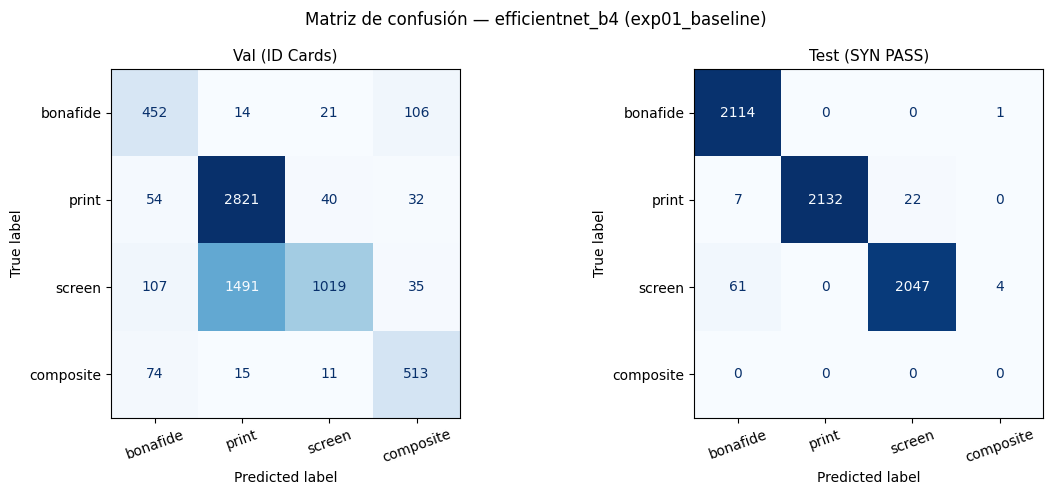

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/confusion_matrices/confmat_efficientnet_b4.png
  MobileNetV3-Large               :    329,476 entrenables /    4,531,508 (7.3%)


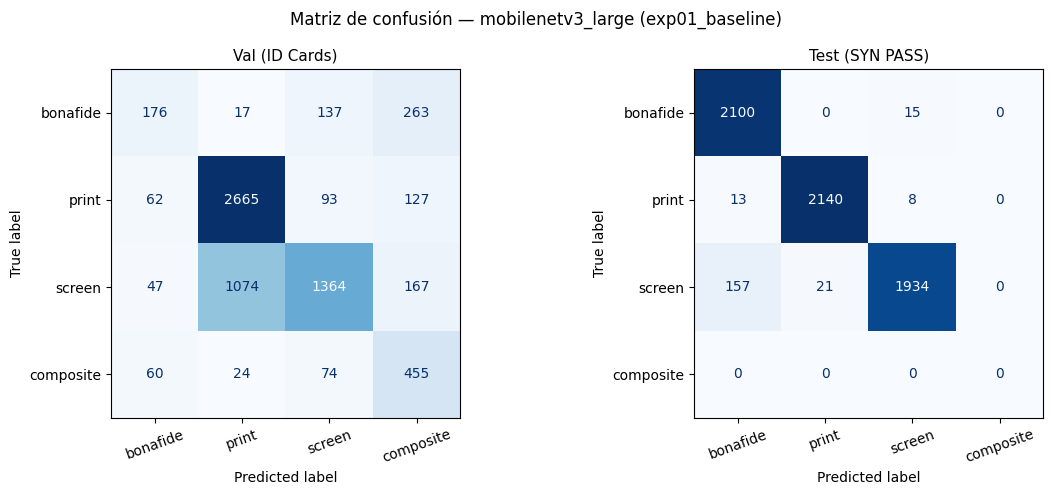

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/confusion_matrices/confmat_mobilenetv3_large.png


  DINOv2 ViT-B/14 (unfreeze=0)    :    198,404 entrenables /   85,923,332 (0.2%)


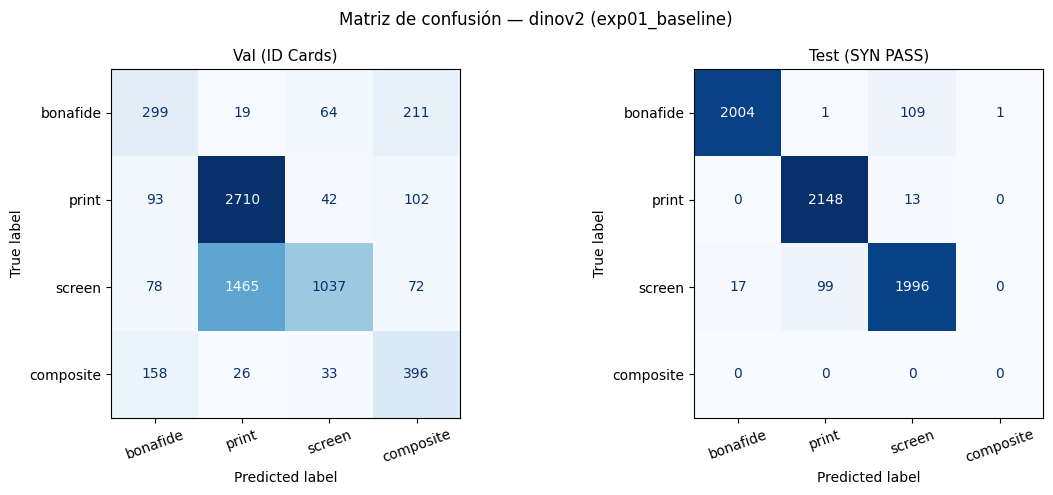

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/confusion_matrices/confmat_dinov2.png


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


  CLIP ViT-B/32                   : 14,308,612 entrenables /   87,982,084 (16.3%)


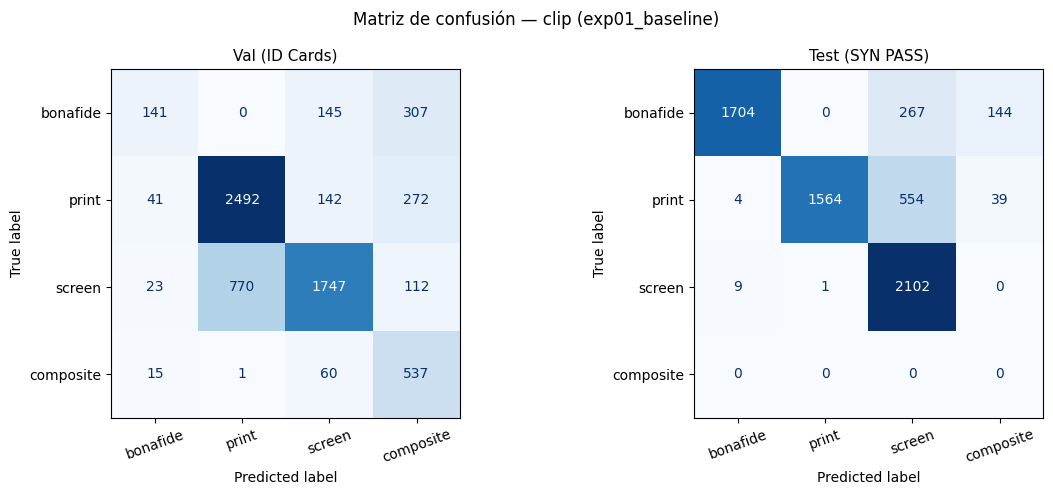

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/confusion_matrices/confmat_clip.png


In [ ]:

CONF_DIR = H2_BASE_DIR / 'confusion_matrices'
CONF_DIR.mkdir(exist_ok=True)

exp_base = next(e for e in EXPERIMENTS_TO_RUN if e['exp_id'] == 'exp01_baseline')
config   = build_config(BASE_CONFIG, exp_base)
_, loader_val_cm, loader_test_cm, _ = build_dataloaders(TRAIN_DF, VAL_DF, TEST_DF, config)

for mn in exp_base['models_to_train']:
    runs     = ALL_RESULTS['exp01_baseline'].get(mn, [])
    if not runs: continue
    best_idx = int(np.argmin([r['val']['EER'] for r in runs]))
    best_seed = runs[best_idx]['run_seed']
    ckpt_best = H2_BASE_DIR / 'exp01_baseline' / 'checkpoints' / f'{mn}_run{best_seed}_best.pt'
    if not ckpt_best.exists(): continue

    model = get_model(mn, run_seed=best_seed, config=config)
    model.load_state_dict(torch.load(str(ckpt_best), map_location=DEVICE, weights_only=True))
    model.eval()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (loader, titulo) in zip(axes, [(loader_val_cm,'Val (ID Cards)'),
                                            (loader_test_cm,'Test (SYN PASS)')]):
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, lm, _ in loader:
                logits = model(imgs.to(DEVICE))
                preds  = logits.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds); all_labels.extend(lm.numpy())
        cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(CLASS_NAMES))))
        disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'{titulo}', fontsize=11)
        ax.tick_params(axis='x', rotation=20)
    plt.suptitle(f'Matriz de confusión — {mn} (exp01_baseline)', fontsize=12)
    plt.tight_layout()
    path = str(CONF_DIR / f'confmat_{mn}.png')
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {path}')
    del model; gc.collect(); torch.cuda.empty_cache()

In [ ]:
backup = H2_BASE_DIR / f'ALL_RESULTS_backup_{datetime.date.today()}.json'
with open(backup, 'w') as f:
    json.dump(ALL_RESULTS, f, indent=2)
print(f'Backup  {backup}')